# Spotify Song Clustering Project (Full Data Version)



# Load Libraries

In [2]:
!pip -q install -U pandas numpy scikit-learn scipy matplotlib seaborn umap-learn wordcloud joblib nltk

import os, re, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, normalize, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning

import umap
from wordcloud import WordCloud
import joblib
import ast
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# --- Sentiment (VADER via NLTK) ---
# If this fails (e.g., no internet), we fall back to a neutral sentiment score = 0.
try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    nltk.download("vader_lexicon", quiet=True)
    _SIA = SentimentIntensityAnalyzer()
except Exception as _e:
    print("Warning: VADER sentiment unavailable; sentiment scores will be 0. Error:", _e)
    _SIA = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf

# Load Datasets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/Shareddrives/ML1/FinalProject/Code/"

FILE_MAIN_FULL   = os.path.join(DATA_DIR, "songs_with_attributes_and_lyrics.csv")
FILE_MAIN_SAMPLE = os.path.join(DATA_DIR, "sample_50k_songs_with_attributes_and_lyrics.csv")

FILE_LYR_TS_FULL   = os.path.join(DATA_DIR, "songs_with_lyrics_and_timestamps.csv")
FILE_LYR_TS_SAMPLE = os.path.join(DATA_DIR, "sample_50k_songs_with_lyrics_and_timestamps.csv")

FILE_SPOTIFY = os.path.join(DATA_DIR, "SpotifyFeatures.csv")

USE_FULL_DATA = True
FILE_MAIN = FILE_MAIN_FULL if USE_FULL_DATA else FILE_MAIN_SAMPLE

print("Main:", FILE_MAIN, "exists =", os.path.exists(FILE_MAIN))
print("SpotifyFeatures exists =", os.path.exists(FILE_SPOTIFY))

# ====== Configurations ======
BASE_SAMPLE_N = 120_000
EDA_SAMPLE_N  = 20_000
K_SELECT_N    = 40_000
TEXT_FIT_N    = 80_000        # TF-IDF + SVD sample size

CHUNK_SIZE = 50_000

MAX_FEATURES   = 6000         # TF-IDF vocab size
SVD_COMPONENTS = 80

# KMeans Configurations
K_OVERRIDE = 8
BATCH_SIZE = 4096

# ====== Feature Weights ======
AUDIO_WEIGHT = 1.0
TEXT_WEIGHT  = 1.0
L2_NORMALIZE = True   # True

TRAIN_ON_FULL = False

CACHE_TAG = "v6_sup_wps"

print("USE_FULL_DATA =", USE_FULL_DATA)
print("TRAIN_ON_FULL =", TRAIN_ON_FULL)
print("AUDIO_WEIGHT =", AUDIO_WEIGHT, "| TEXT_WEIGHT =", TEXT_WEIGHT, "| L2_NORMALIZE =", L2_NORMALIZE)
print("CACHE_TAG =", CACHE_TAG)



Mounted at /content/drive
Main: /content/drive/Shareddrives/ML1/FinalProject/Code/songs_with_attributes_and_lyrics.csv exists = True
SpotifyFeatures exists = True
USE_FULL_DATA = True
TRAIN_ON_FULL = False
AUDIO_WEIGHT = 1.0 | TEXT_WEIGHT = 1.0 | L2_NORMALIZE = True
CACHE_TAG = v6_sup_wps


In [4]:
song_atr = pd.read_csv(FILE_MAIN_FULL)
song_ts = pd.read_csv(FILE_LYR_TS_FULL)
song_fea = pd.read_csv(FILE_SPOTIFY)

In [5]:
song_atr.columns

Index(['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics'],
      dtype='object')

In [6]:
song_ts.head(5)

,id,startTimeMs,words
0,000TJYlDLPM01ebX8QtIUS,42710,Siento escapar mi vida
1,000TJYlDLPM01ebX8QtIUS,70350,"que triste se va, triste termina."
2,000TJYlDLPM01ebX8QtIUS,74780,Intento olvidar tu gran herida
3,000TJYlDLPM01ebX8QtIUS,87530,"que siendo mortal, es también mía."
4,000TJYlDLPM01ebX8QtIUS,94990,Tal vez podré algún día surcar otra vez


In [7]:
song_fea.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [8]:
song_atr.columns

Index(['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics'],
      dtype='object')

# Tool Functions


In [9]:
# Columns Used
AUDIO_NUM_COLS = [
    "danceability","energy","loudness","speechiness","acousticness",
    "instrumentalness","liveness","valence","tempo","duration_ms"
]
KEY_MODE_COLS = ["key","mode"]

# --- Derived NLP/audio-text numeric features ---
# We keep only word_per_sec and sentiment in the final model feature vector.
# lyric_word_count is still computed as an auxiliary column for EDA and to build word_per_sec,
# but it is excluded from clustering / supervised modeling to avoid redundant weighting with
# duration_ms and word_per_sec.
DERIVED_NUM_COLS = ["word_per_sec", "sentiment"]
AUDIO_MODEL_NUM_COLS = AUDIO_NUM_COLS + DERIVED_NUM_COLS
AUDIO_MEAN_COLS = AUDIO_MODEL_NUM_COLS  # numeric columns summarized at the cluster level
AUX_TEXT_DIAG_COLS = ["lyric_word_count"]

# Sentiment / rate settings
USE_SENTIMENT = True
SENTIMENT_MAX_CHARS = 2000  # truncate lyrics for speed
WORD_PER_SEC_CLIP = 20.0    # clip extreme outliers

USECOLS_SAMPLE = ["id","name","artists"] + KEY_MODE_COLS + AUDIO_NUM_COLS + ["lyrics"]
USECOLS_FULL = ["id"] + KEY_MODE_COLS + AUDIO_NUM_COLS + ["lyrics"]

DTYPE_NUM = {c: "float32" for c in AUDIO_NUM_COLS}

# Safely extracts the first artist from a string that looks like a Python list
def safe_parse_artists(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list) and len(val) > 0:
                return str(val[0])
            return str(val)
        except Exception:
            return s
    return s

# ========= Text Preprocessing =========
_whitespace_re = re.compile(r"\s+")
_apost_re = re.compile(r"[’']")

# Removes apostrophes, collapsing whitespace, lowercasing, and returning a clean string.
def text_preprocess(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).replace("\n", " ").replace("\t", " ")
    s = _apost_re.sub("", s)  # don't -> dont, I'll -> ill
    s = _whitespace_re.sub(" ", s).strip().lower()
    return s


# Compute lyric_word_count, word_per_sec, and sentiment (VADER) in a chunk-friendly way.
def add_text_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df  # modify in place to save memory (chunks can be large)

    # Ensure required columns exist
    if "lyrics" not in out.columns:
        out["lyrics"] = ""
    if "duration_ms" not in out.columns:
        out["duration_ms"] = np.nan

    # Clean lyrics once
    lyr = out["lyrics"].fillna("").astype(str).map(text_preprocess)
    lyr_list = lyr.tolist()

    # Word count
    wc = np.fromiter((len(t.split()) if t else 0 for t in lyr_list), dtype=np.float32, count=len(lyr_list))
    out["lyric_word_count"] = wc

    # Words per second
    dur_ms = pd.to_numeric(out["duration_ms"], errors="coerce").fillna(0).to_numpy(dtype=np.float32)
    dur_sec = np.maximum(dur_ms / 1000.0, 1.0)  # avoid divide-by-zero; treat <1s as 1s
    wps = (wc / dur_sec).astype(np.float32)
    wps = np.clip(wps, 0.0, WORD_PER_SEC_CLIP).astype(np.float32)
    out["word_per_sec"] = wps

    # Sentiment (VADER compound)
    if USE_SENTIMENT and "_SIA" in globals() and _SIA is not None:
        sent = np.fromiter(
            (float(_SIA.polarity_scores(t[:SENTIMENT_MAX_CHARS])["compound"]) if t else 0.0 for t in lyr_list),
            dtype=np.float32,
            count=len(lyr_list),
        )
    else:
        sent = np.zeros(len(lyr_list), dtype=np.float32)
    out["sentiment"] = sent

    return out

# Draws an approximately uniform random sample of n rows from a huge CSV using chunked reading.
def priority_sample_csv(path, n, usecols, dtype=None, chunksize=100_000, random_state=42):
    rng = np.random.default_rng(random_state)
    sample = None

    for chunk in pd.read_csv(path, usecols=usecols, dtype=dtype, chunksize=chunksize):
        chunk = chunk.copy()
        chunk["_rand"] = rng.random(len(chunk), dtype=np.float64)

        if sample is None:
            sample = chunk.nsmallest(n, "_rand")
        else:
            thr = sample["_rand"].max()
            cand = chunk[chunk["_rand"] < thr]
            if len(cand) > 0:
                sample = pd.concat([sample, cand], ignore_index=True)
                sample = sample.nsmallest(n, "_rand")

    sample = sample.drop(columns=["_rand"]).reset_index(drop=True)
    return sample

def report_missingness(df, cols):
    return df[cols].isna().mean().sort_values(ascending=False)

def top_correlations(df, cols, top_n=10):
    corr = df[cols].corr(numeric_only=True)
    pairs = []
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            a, b = cols[i], cols[j]
            val = corr.loc[a, b]
            if pd.notna(val):
                pairs.append((a, b, float(val), abs(float(val))))
    pairs = sorted(pairs, key=lambda x: x[3], reverse=True)[:top_n]
    return pd.DataFrame(pairs, columns=["feature_1","feature_2","corr","abs_corr"])

_KEY_MAP = {
    "C": 0, "C#": 1, "DB": 1,
    "D": 2, "D#": 3, "EB": 3,
    "E": 4,
    "F": 5, "F#": 6, "GB": 6,
    "G": 7, "G#": 8, "AB": 8,
    "A": 9, "A#": 10, "BB": 10,
    "B": 11
}

# Converts a key column into numeric pitch classes (0–11)
def parse_key_series(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    need = num.isna() & s.notna()
    if need.any():
        ss = s[need].astype(str).str.strip()
        m = ss.str.extract(r"^([A-Ga-g])\s*([#b♯♭]?)", expand=True)
        note = m[0].str.upper()
        acc = m[1].fillna("").replace({"♯": "#", "♭": "b"})
        canon = (note + acc).fillna("")
        canon2 = canon.str.replace("b", "B", regex=False)  # Db -> DB
        num.loc[need] = canon2.map(_KEY_MAP)
    return num

# Converts a mode column into numeric values (major=1, minor=0)
def parse_mode_series(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    need = num.isna() & s.notna()
    if need.any():
        ss = s[need].astype(str).str.strip().str.lower()
        mapped = pd.Series(np.nan, index=ss.index)
        mapped.loc[ss.str.startswith("maj")] = 1
        mapped.loc[ss.str.startswith("min")] = 0
        mapped.loc[ss.isin(["true","t","yes","y"])] = 1
        mapped.loc[ss.isin(["false","f","no","n"])] = 0
        num.loc[need] = mapped
    return num

AUDIO_FEATURE_NAMES = (
    AUDIO_MODEL_NUM_COLS + ["key_sin","key_cos","mode","key_missing","mode_missing"]
)

# Builds the final standardized audio feature matrix
def make_audio_matrix(df, imp_audio=None, scaler_audio=None, fit=False):
    tmp = df.copy()

    tmp["key"] = parse_key_series(tmp["key"])
    tmp["mode"] = parse_mode_series(tmp["mode"])

    # Derived text-based numeric features (compute if missing)
    if not set(DERIVED_NUM_COLS).issubset(set(tmp.columns)):
        tmp = add_text_numeric_features(tmp)

    key_missing = tmp["key"].isna().astype("int8").to_numpy().reshape(-1, 1)
    mode_missing = tmp["mode"].isna().astype("int8").to_numpy().reshape(-1, 1)

    if fit:
        imp_km = SimpleImputer(strategy="most_frequent")
        km = imp_km.fit_transform(tmp[KEY_MODE_COLS])
    else:
        km = imp_audio["imp_km"].transform(tmp[KEY_MODE_COLS])

    key = km[:, 0].astype(np.float32)
    mode = km[:, 1].astype(np.float32)

    key = np.mod(key, 12.0)
    key_sin = np.sin(2 * np.pi * key / 12.0).reshape(-1, 1).astype(np.float32)
    key_cos = np.cos(2 * np.pi * key / 12.0).reshape(-1, 1).astype(np.float32)
    mode = mode.reshape(-1, 1).astype(np.float32)

    if fit:
        imp_num = SimpleImputer(strategy="median")
        num = imp_num.fit_transform(tmp[AUDIO_MODEL_NUM_COLS])
    else:
        num = imp_audio["imp_num"].transform(tmp[AUDIO_MODEL_NUM_COLS])

    num = num.astype(np.float32)

    X_audio = np.hstack([num, key_sin, key_cos, mode, key_missing, mode_missing]).astype(np.float32)

    if fit:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_audio).astype(np.float32)
        pack = {
            "imp_num": imp_num,
            "imp_km": imp_km,
            "scaler": scaler,
        }
        return X_scaled, pack
    else:
        X_scaled = scaler_audio.transform(X_audio).astype(np.float32)
        return X_scaled

# ========= Text Vectors：TF-IDF -> SVD =========
LYRIC_STOPWORDS_EXTRA = {

    "oh","ooh","woo","yeah","yea","yah","ya","hey","ha","ah","la","na","nah","uh","mmm",

    "chorus","verse","bridge","intro","outro","repeat","refrain",

    "gonna","wanna","gotta","aint","dont","cant","wont","im","ive","youre","were","thats","theres",

    "ain","don","didn","doesn","isn","wasn","weren","couldn","shouldn","wouldn","havent","hasnt","hadnt",

    "baby","like"
}

STOPWORDS = set(ENGLISH_STOP_WORDS).union(LYRIC_STOPWORDS_EXTRA)

# Fits a TF-IDF→SVD→StandardScaler pipeline on non-empty lyrics with fallbacks to looser tokenization or char n-grams if the vocabulary is empty.
def fit_text_models(text_series, max_features=6000, svd_components=80):

    raw = pd.Series(text_series).fillna("").astype(str)

    pre = raw.map(text_preprocess)
    mask = pre.str.contains(r"\w", regex=True)
    raw_fit = raw[mask]

    print(f"[Text fit] usable lyrics: {len(raw_fit)}/{len(raw)} ({len(raw_fit)/max(1,len(raw)):.1%})")
    if len(raw_fit) == 0:
        raise ValueError("No usable lyrics in sample after preprocessing.")

    tfidf = TfidfVectorizer(
        preprocessor=text_preprocess,
        stop_words=sorted(STOPWORDS),
        token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
        max_features=max_features,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 1),
        dtype=np.float32
    )

    try:
        X_tfidf = tfidf.fit_transform(raw_fit)
        if X_tfidf.shape[1] == 0:
            raise ValueError("empty vocab")
    except ValueError:
        print("[Text fit] Word TF-IDF empty vocab -> fallback to looser token_pattern")
        tfidf = TfidfVectorizer(
            preprocessor=text_preprocess,
            stop_words=sorted(STOPWORDS),
            token_pattern=r"(?u)\b\w\w+\b",
            max_features=max_features,
            min_df=2,
            max_df=0.95,
            ngram_range=(1, 1),
            dtype=np.float32
        )
        try:
            X_tfidf = tfidf.fit_transform(raw_fit)
            if X_tfidf.shape[1] == 0:
                raise ValueError("empty vocab")
        except ValueError:
            print("[Text fit] Still empty -> fallback to char_wb 3-5grams")
            tfidf = TfidfVectorizer(
                preprocessor=text_preprocess,
                analyzer="char_wb",
                ngram_range=(3, 5),
                max_features=max_features,
                min_df=2,
                dtype=np.float32
            )
            X_tfidf = tfidf.fit_transform(raw_fit)

    n_features = X_tfidf.shape[1]
    if n_features <= 1:
        svd = None
        X_svd = X_tfidf.toarray().astype(np.float32)
    else:
        n_comp = int(min(svd_components, n_features - 1))
        svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
        X_svd = svd.fit_transform(X_tfidf).astype(np.float32)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_svd).astype(np.float32)

    pack = {"tfidf": tfidf, "svd": svd, "scaler": scaler}
    return X_scaled, pack

# Applies the fitted TF-IDF/SVD/scaler pipeline to new lyrics and returns standardized text embeddings.
def transform_text_models(text_series, text_pack):
    raw = pd.Series(text_series).fillna("").astype(str)
    X_tfidf = text_pack["tfidf"].transform(raw)

    svd = text_pack.get("svd", None)
    if svd is None:
        X_svd = X_tfidf.toarray().astype(np.float32)
    else:
        X_svd = svd.transform(X_tfidf).astype(np.float32)

    X_scaled = text_pack["scaler"].transform(X_svd).astype(np.float32)
    return X_scaled

# Concatenates weighted audio and text features into a single matrix and optionally applies L2 normalization
def build_feature_matrix(df, audio_pack, text_pack, audio_weight=1.0, text_weight=1.0, l2_normalize=False):
    X_audio_scaled = make_audio_matrix(df, imp_audio=audio_pack, scaler_audio=audio_pack["scaler"], fit=False)
    X_text = transform_text_models(df["lyrics"], text_pack)
    X = np.hstack([X_audio_scaled * audio_weight, X_text * text_weight]).astype(np.float32)
    if l2_normalize:
        X = normalize(X).astype(np.float32)
    return X


# Returns the final feature names used after audio engineering + text SVD.
def get_final_feature_names(audio_pack, text_pack, extra_num_cols=None):

    text_dim = getattr(text_pack["scaler"], "n_features_in_", None)

    if text_dim is None:
        svd_obj = text_pack.get("svd", None)
        if svd_obj is not None and hasattr(svd_obj, "n_components"):
            text_dim = int(svd_obj.n_components)
        else:
            text_dim = int(len(text_pack["tfidf"].get_feature_names_out()))

    text_names = [f"lyric_svd_{i+1}" for i in range(int(text_dim))]

    if extra_num_cols is None:
        extra_num_cols = []

    return list(AUDIO_FEATURE_NAMES) + text_names + list(extra_num_cols)





## Draw Samples


In [10]:
print("Sampling from:", FILE_MAIN)
df_base = priority_sample_csv(
    FILE_MAIN,
    n=BASE_SAMPLE_N,
    usecols=USECOLS_SAMPLE,
    dtype=DTYPE_NUM,
    chunksize=CHUNK_SIZE,
    random_state=RANDOM_STATE
)

# Some basic-level cleaning
df_base = df_base.drop_duplicates(subset=["id"]).copy()
df_base["artist_main"] = df_base["artists"].apply(safe_parse_artists)

print("df_base shape:", df_base.shape)
display(df_base.head(3))


Sampling from: /content/drive/Shareddrives/ML1/FinalProject/Code/songs_with_attributes_and_lyrics.csv
df_base shape: (120000, 17)


,id,name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,artist_main
0,0ag5AQEUFN4u1IwKysGf8e,The Spiritual,['Jukebox The Ghost'],0.499,0.364,6,-9.329,1,0.0284,0.6470,0.000003,0.1920,0.287,73.990997,228729.0,"Some walk quiet, some walk loud\n Sometimes pe...",Jukebox The Ghost
1,3prGI7hz4h7eDofFRQm6DH,La Tracalera,['Los Traileros Del Norte'],0.716,0.815,10,-7.939,1,0.0748,0.0750,0.830000,0.0297,0.983,190.626007,154147.0,"La invite, con la mirada, y me puse a bailar c...",Los Traileros Del Norte
2,60SdxE8apGAxMiRrpbmLY0,Lucky You (feat. Joyner Lucas),Eminem,0.876,0.786,10,-4.884,0,0.3060,0.0627,0.000000,0.1270,0.575,153.067993,244679.0,"Whoa, Joyner, Joyner, yeah, yeah, yeah\n ♪\n Y...",Eminem


## EDA on Sample

- High Correlation Features
  - PCA
  - Delete Features

- Missing values for Key/Mode
  - Impute with most_frequent
  - Use sin/cos for keys

In [11]:
# Missing Rate
cols_for_missing = ["artists","name"] + KEY_MODE_COLS + AUDIO_NUM_COLS + ["lyrics"]
miss = report_missingness(df_base, cols_for_missing)
print("Missing rate (top 15) on sample:")
display(miss.head(15))

Missing rate (top 15) on sample:


,0
name,0.000008
lyrics,0.000008
artists,0.000000
mode,0.000000
danceability,0.000000
energy,0.000000
key,0.000000
loudness,0.000000
speechiness,0.000000
instrumentalness,0.000000


Top correlations among audio numeric features (sample):


,feature_1,feature_2,corr,abs_corr
0,energy,loudness,0.766279,0.766279
1,energy,acousticness,-0.721520,0.721520
2,loudness,acousticness,-0.558751,0.558751
3,danceability,valence,0.498021,0.498021
4,energy,valence,0.212499,0.212499
5,energy,tempo,0.198723,0.198723
6,valence,duration_ms,-0.193539,0.193539
7,danceability,instrumentalness,-0.187033,0.187033
8,instrumentalness,valence,-0.184186,0.184186
9,energy,liveness,0.174980,0.174980


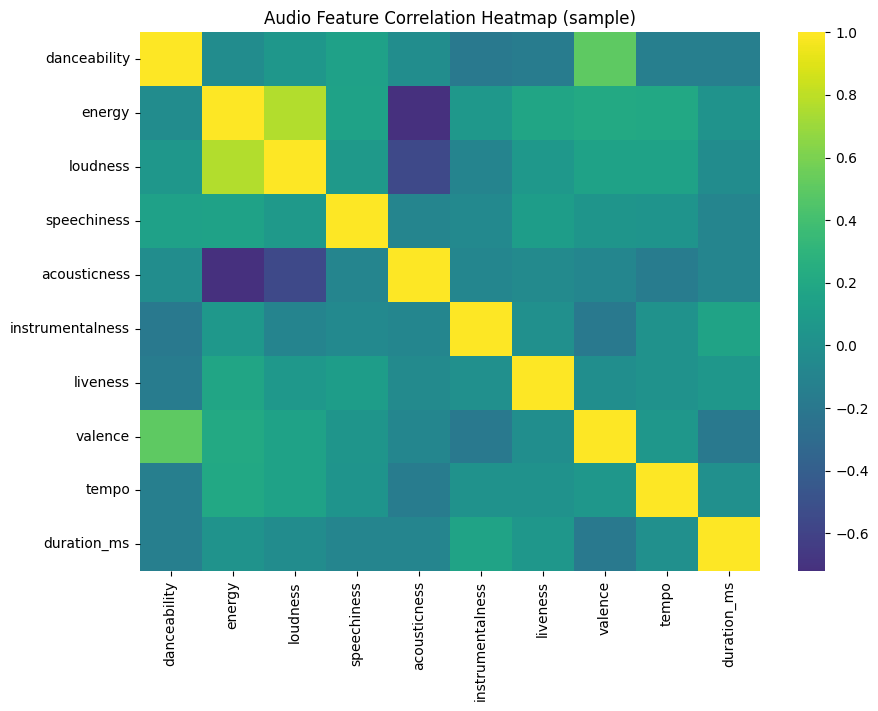

In [12]:
# Correlation Matrix
corr_top = top_correlations(df_base, AUDIO_NUM_COLS, top_n=12)
print("Top correlations among audio numeric features (sample):")
display(corr_top)

# Correlation Heatmap
plt.figure(figsize=(10, 7))
corr = df_base[AUDIO_NUM_COLS].corr(numeric_only=True)
sns.heatmap(corr, cmap="viridis", center=0)
plt.title("Audio Feature Correlation Heatmap (sample)")
plt.show()

Note: lyric_word_count is kept only as an auxiliary diagnostic variable. The final model feature vector keeps word_per_sec and sentiment, and excludes lyric_word_count to avoid redundant weighting with duration_ms.


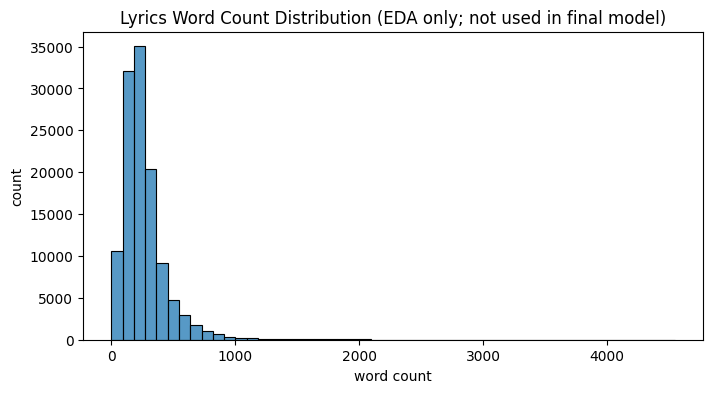

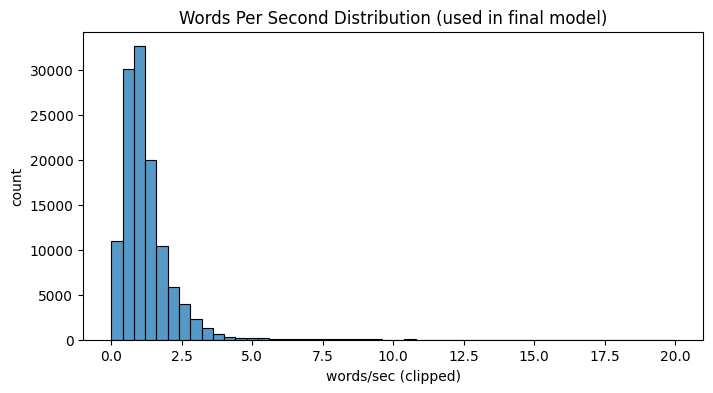

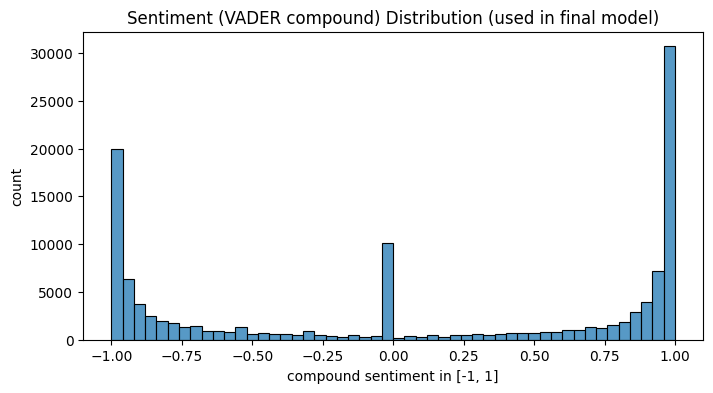

In [13]:
# Derived features for EDA (sample)
df_base = add_text_numeric_features(df_base)

print(
    "Note: lyric_word_count is kept only as an auxiliary diagnostic variable. "
    "The final model feature vector keeps word_per_sec and sentiment, and excludes lyric_word_count "
    "to avoid redundant weighting with duration_ms."
)

plt.figure(figsize=(8, 4))
sns.histplot(df_base["lyric_word_count"], bins=50)
plt.title("Lyrics Word Count Distribution (EDA only; not used in final model)")
plt.xlabel("word count")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_base["word_per_sec"], bins=50)
plt.title("Words Per Second Distribution (used in final model)")
plt.xlabel("words/sec (clipped)")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_base["sentiment"], bins=50)
plt.title("Sentiment (VADER compound) Distribution (used in final model)")
plt.xlabel("compound sentiment in [-1, 1]")
plt.ylabel("count")
plt.show()


In [14]:
mode_map = {
    "Major": 1,
    "Minor": 0
}

df_base["mode"] = (
    df_base["mode"]
    .replace(mode_map)     # convert strings
    .astype(float)         # convert 1.0 / 0.0
    .astype(int)           # final integer
)

key_map = {
    "C":0, "C#":1, "D":2, "D#":3,
    "E":4, "F":5, "F#":6,
    "G":7, "G#":8,
    "A":9, "A#":10,
    "B":11
}

df_base["key"] = (
    df_base["key"]
    .replace(key_map)      # convert note names
    .astype(float)         # convert 0.0,1.0,...
    .astype(int)           # final integer
)

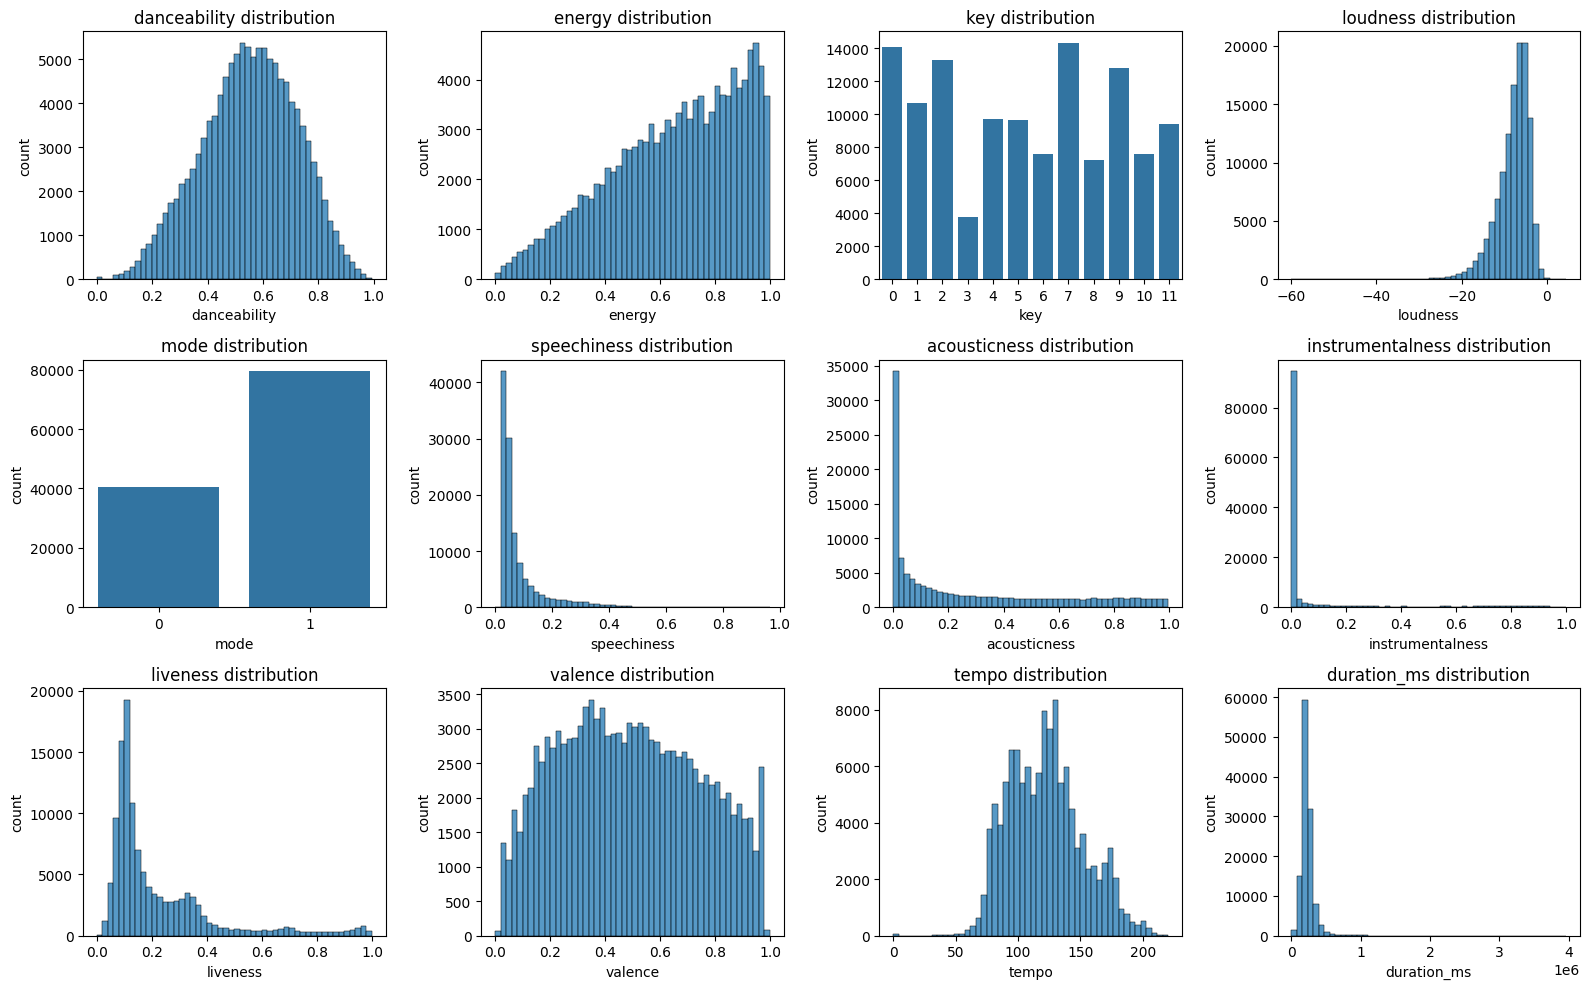

In [15]:
def plot_hist(df, col):
  discrete_cols = ["key", "mode"]

  n_cols = 4
  n_rows = (len(cols) + n_cols - 1) // n_cols

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
  axes = axes.flatten()

  for i, col in enumerate(cols):

      if col in discrete_cols:
          sns.countplot(x=df[col], ax=axes[i])
      else:
          sns.histplot(df[col], bins=50, ax=axes[i])

      axes[i].set_title(f"{col} distribution")
      axes[i].set_xlabel(col)
      axes[i].set_ylabel("count")

  # remove unused axes
  for j in range(i+1, len(axes)):
      fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

cols = [
    'danceability','energy','key','loudness','mode','speechiness',
    'acousticness','instrumentalness','liveness','valence',
    'tempo','duration_ms'
]
plot_hist(df_base, cols)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


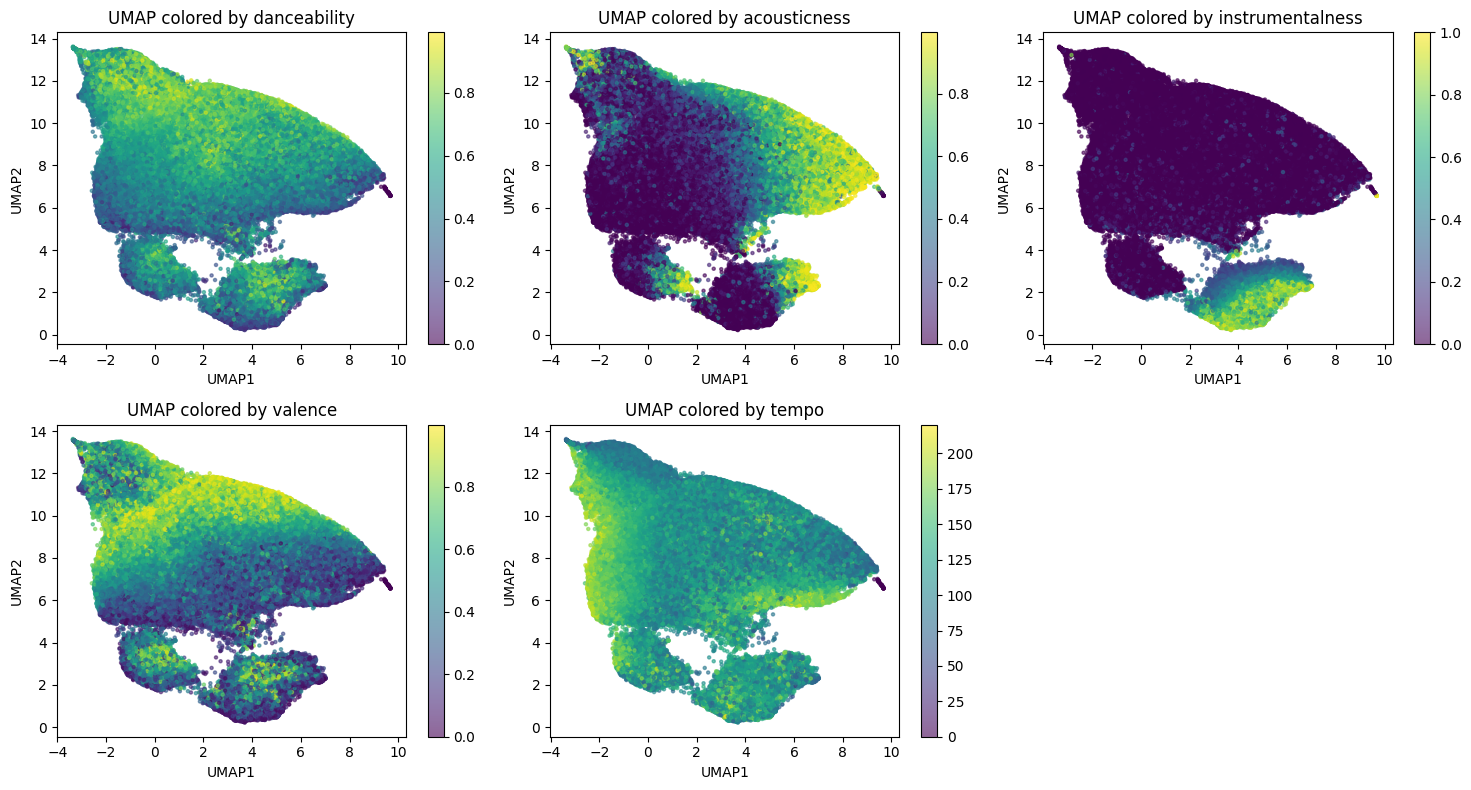

In [16]:
feature_cols = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo','duration_ms'
]

X = df_base[feature_cols]

X_scaled = StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

features = [
    "danceability",
    "acousticness",
    "instrumentalness",
    "valence",
    "tempo"
]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):

    sc = axes[i].scatter(
        X_umap[:,0],
        X_umap[:,1],
        c=df_base[feat],
        cmap="viridis",
        s=5,
        alpha=0.6
    )

    axes[i].set_title(f"UMAP colored by {feat}")
    axes[i].set_xlabel("UMAP1")
    axes[i].set_ylabel("UMAP2")

    fig.colorbar(sc, ax=axes[i])

# remove empty subplot if needed
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Merging feature and main datasets

In [17]:
extra_cols = ["genre", "popularity", "track_id"]
song_fea_unique = song_fea.drop_duplicates(subset="track_id").copy()

df_merge = song_atr.merge(
    song_fea_unique[extra_cols],
    left_on="id",
    right_on="track_id",
    how="left"
)

df_merge = df_merge.drop(columns=["track_id"])
df_merge = df_merge.dropna(subset=["genre", "popularity"]).copy()
df_merge["genre"] = df_merge["genre"].astype(str).str.strip()


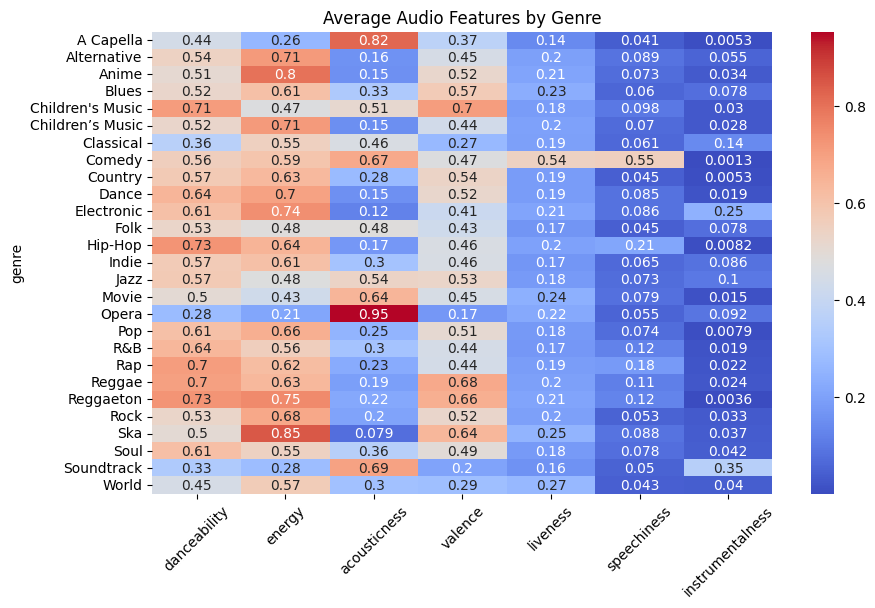

In [18]:
genre_means = df_merge.groupby("genre")[
    ["danceability","energy","acousticness","valence",'liveness','speechiness','instrumentalness']
].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    genre_means,
    cmap="coolwarm",
    annot=True
)

plt.xticks(rotation=45)   # rotate feature names
plt.yticks(rotation=0)    # keep genre readable

plt.title("Average Audio Features by Genre")
plt.show()

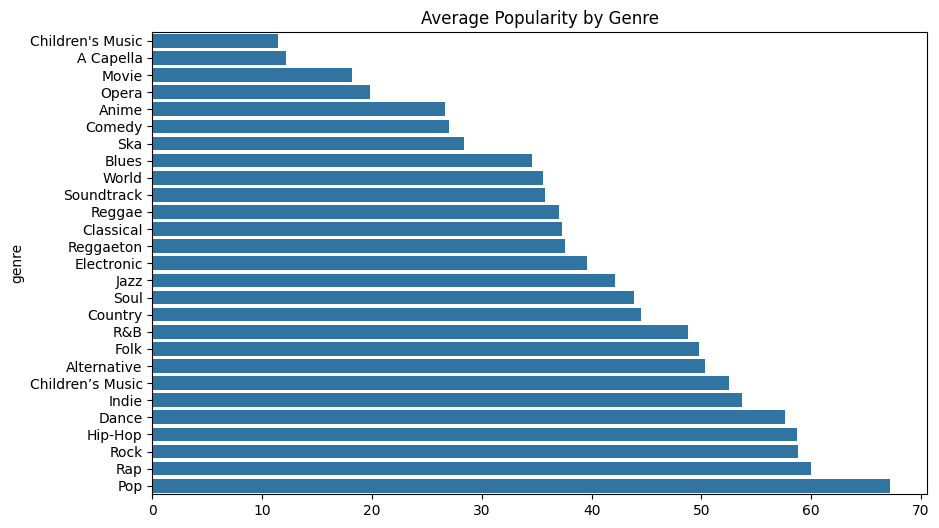

In [19]:
genre_sentiment = df_merge.groupby("genre")["popularity"].mean().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=genre_sentiment.values,
    y=genre_sentiment.index
)

plt.title("Average Popularity by Genre")
plt.show()

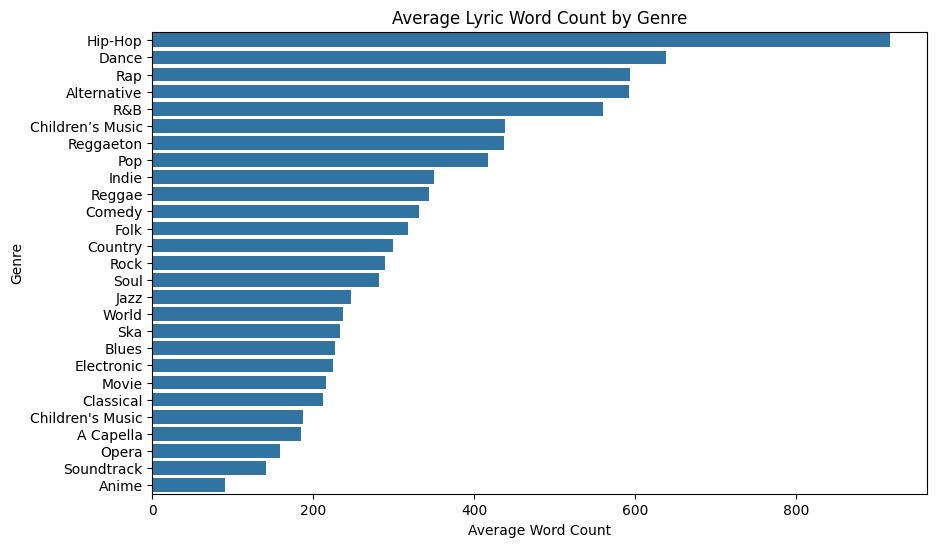

In [20]:
df_merge["text_preprocess"] = df_merge["lyrics"].apply(text_preprocess)
df_merge["word_count"] = df_merge["text_preprocess"].str.split().apply(len)
genre_word_avg = (
    df_merge.groupby("genre")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=genre_word_avg.values,
    y=genre_word_avg.index
)

plt.title("Average Lyric Word Count by Genre")
plt.xlabel("Average Word Count")
plt.ylabel("Genre")

plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


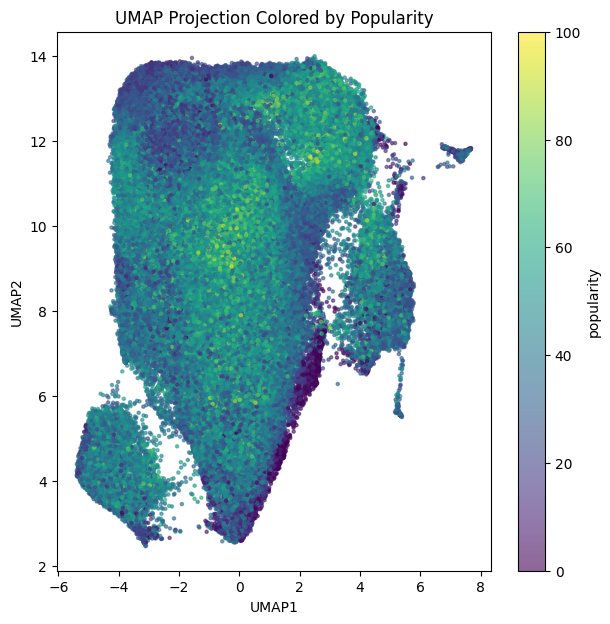

In [21]:
feature_cols = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo','duration_ms','popularity'
]

X = df_merge[feature_cols].astype("float32")

X_scaled = StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(7,7))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=df_merge["popularity"],
    cmap="viridis",
    s=5,
    alpha=0.6
)

plt.colorbar(label="popularity")

plt.title("UMAP Projection Colored by Popularity")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.show()

## Modeling on Sample

- `audio_pack`：Audio's imputer + scaler
- `text_pack`：TF-IDF + SVD + scaler
- `kmeans_sample`

This cell prepares and caches the feature-engineering pipeline for clustering by building (or loading) audio and text feature transformers, sampling subsets of the dataset for different tasks, and constructing the feature matrix used for selecting the number of clusters.

In [22]:
CACHE_DIR = os.path.join(DATA_DIR, "_ml_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

AUDIO_PACK_PATH = os.path.join(CACHE_DIR, f"audio_pack_{CACHE_TAG}.joblib")
TEXT_PACK_PATH  = os.path.join(CACHE_DIR, f"text_pack_{CACHE_TAG}_tfidf{MAX_FEATURES}_svd{SVD_COMPONENTS}.joblib")
KMEANS_PATH     = os.path.join(CACHE_DIR, f"minibatch_kmeans_{CACHE_TAG}_k{K_OVERRIDE}_tfidf{MAX_FEATURES}_svd{SVD_COMPONENTS}.joblib")


# df_eda = df_merge.sample(n=min(EDA_SAMPLE_N, len(df_merge)), random_state=RANDOM_STATE).reset_index(drop=True)
# df_k   = df_merge.sample(n=min(K_SELECT_N, len(df_merge)), random_state=RANDOM_STATE+1).reset_index(drop=True)
# df_fit = df_merge.sample(n=min(TEXT_FIT_N, len(df_merge)), random_state=RANDOM_STATE+2).reset_index(drop=True)

df_eda = df_base.sample(n=min(EDA_SAMPLE_N, len(df_base)), random_state=RANDOM_STATE).reset_index(drop=True)
df_k   = df_base.sample(n=min(K_SELECT_N, len(df_base)), random_state=RANDOM_STATE+1).reset_index(drop=True)
df_fit = df_base.sample(n=min(TEXT_FIT_N, len(df_base)), random_state=RANDOM_STATE+2).reset_index(drop=True)

print("df_eda:", df_eda.shape, "| df_k:", df_k.shape, "| df_fit:", df_fit.shape)

# ===== 5A) audio_pack =====
if os.path.exists(AUDIO_PACK_PATH):
    audio_pack = joblib.load(AUDIO_PACK_PATH)
    print("Loaded:", AUDIO_PACK_PATH)
else:
    X_audio_fit, audio_pack = make_audio_matrix(df_fit, fit=True)
    joblib.dump(audio_pack, AUDIO_PACK_PATH)
    print("Saved:", AUDIO_PACK_PATH, "| audio matrix shape:", X_audio_fit.shape)

# ===== 5B) text_pack =====
if os.path.exists(TEXT_PACK_PATH):
    text_pack = joblib.load(TEXT_PACK_PATH)
    print("Loaded:", TEXT_PACK_PATH)
else:
    X_text_fit, text_pack = fit_text_models(df_fit["lyrics"], max_features=MAX_FEATURES, svd_components=SVD_COMPONENTS)
    joblib.dump(text_pack, TEXT_PACK_PATH)
    print("Saved:", TEXT_PACK_PATH, "| text matrix shape:", X_text_fit.shape)
    if text_pack.get("svd", None) is not None:
        print("SVD explained variance sum:", float(text_pack["svd"].explained_variance_ratio_.sum()))

# ===== 5C) Building K-Selection Sample=====
X_k = build_feature_matrix(df_k, audio_pack, text_pack, audio_weight=AUDIO_WEIGHT, text_weight=TEXT_WEIGHT, l2_normalize=L2_NORMALIZE)
print("X_k shape:", X_k.shape, "dtype:", X_k.dtype)



df_eda: (20000, 20) | df_k: (40000, 20) | df_fit: (80000, 20)
Loaded: /content/drive/Shareddrives/ML1/FinalProject/Code/_ml_cache/audio_pack_v6_sup_wps.joblib
Loaded: /content/drive/Shareddrives/ML1/FinalProject/Code/_ml_cache/text_pack_v6_sup_wps_tfidf6000_svd80.joblib
X_k shape: (40000, 97) dtype: float32


## Quickly Select **K** Using a Sample

Running `k = 2..15` on the full dataset is slow since the model must be fit for each **k**.

Instead:

* Run only on **`df_k`** (e.g., 40k sample)
* Use **`MiniBatchKMeans`** (faster than standard KMeans)
* Compute **silhouette** on a subsample to avoid **O(n²)** cost

You can also set **`K_OVERRIDE`** to fix **K** (often clearer for reports).


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7fb12c18d8a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/scipy.libs/libscipy_openblas-b75cc656.

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_share,norm_entropy
0,2,38771.675781,0.029106,5.693775,1193.781332,0.413425,0.978264
1,3,37844.164062,0.031245,5.161728,1102.961400,0.324925,0.999554
2,4,37372.437500,0.025367,5.089544,909.231321,0.137300,0.955092
3,5,36595.113281,0.031801,4.882829,921.340658,0.120350,0.938700
4,6,35749.750000,0.044662,4.357183,939.222146,0.035300,0.887414
5,7,35367.359375,0.041373,4.027980,863.312377,0.034225,0.849549
6,8,35420.964844,0.044183,5.571061,729.229639,0.035000,0.962379
7,9,34710.160156,0.051304,4.149575,764.619092,0.021325,0.894540
8,10,34855.839844,0.045741,4.561100,663.715199,0.034600,0.924680
9,11,34290.058594,0.051855,4.712880,660.279698,0.019500,0.943643


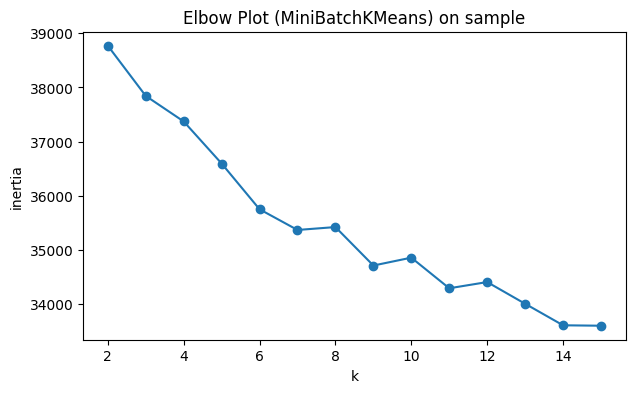

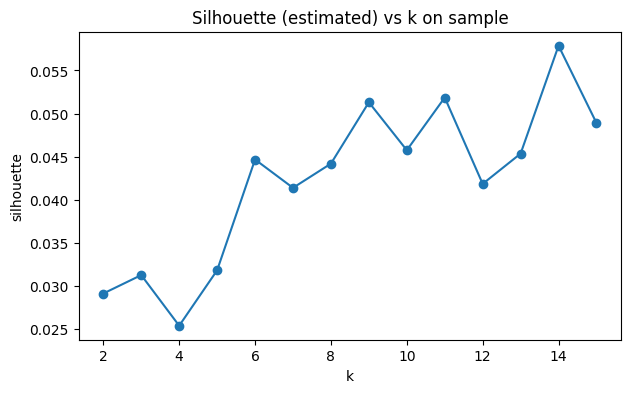

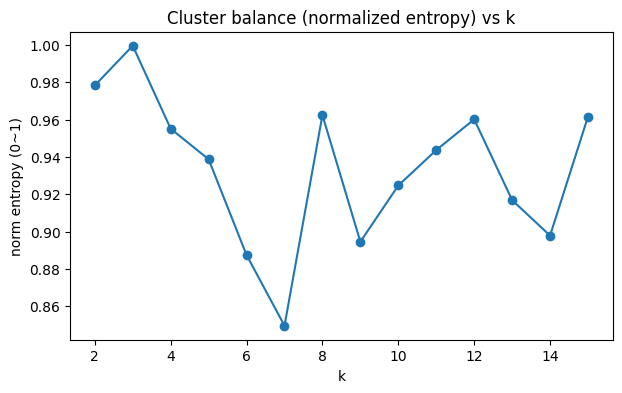

Best k by silhouette (sample): 14 | best silhouette: 0.05787055194377899
Final k used = 8


In [23]:
RUN_K_SEARCH = True

if RUN_K_SEARCH:
    k_range = list(range(2, 16))
    rows = []
    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            batch_size=BATCH_SIZE,
            n_init=5,
            max_iter=100
        )
        labels = km.fit_predict(X_k)

        sil = silhouette_score(X_k, labels, sample_size=min(8000, len(X_k)), random_state=RANDOM_STATE)
        db  = davies_bouldin_score(X_k, labels)
        ch  = calinski_harabasz_score(X_k, labels)

        cnt = np.bincount(labels, minlength=k).astype(np.float64)
        p = cnt / max(cnt.sum(), 1.0)
        min_share = float(p.min())
        entropy = float(-(p * np.log(p + 1e-12)).sum())
        norm_entropy = float(entropy / np.log(k))  # 0~1

        rows.append({
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(sil),
            "davies_bouldin": float(db),
            "calinski_harabasz": float(ch),
            "min_cluster_share": min_share,
            "norm_entropy": norm_entropy
        })

    km_eval = pd.DataFrame(rows).sort_values("k")
    display(km_eval)

    plt.figure(figsize=(7,4))
    plt.plot(km_eval["k"], km_eval["inertia"], marker="o")
    plt.title("Elbow Plot (MiniBatchKMeans) on sample")
    plt.xlabel("k")
    plt.ylabel("inertia")
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(km_eval["k"], km_eval["silhouette"], marker="o")
    plt.title("Silhouette (estimated) vs k on sample")
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(km_eval["k"], km_eval["norm_entropy"], marker="o")
    plt.title("Cluster balance (normalized entropy) vs k")
    plt.xlabel("k")
    plt.ylabel("norm entropy (0~1)")
    plt.show()

    best_k_sil = int(km_eval.loc[km_eval["silhouette"].idxmax(), "k"])
    best_sil = float(km_eval["silhouette"].max())
    print("Best k by silhouette (sample):", best_k_sil, "| best silhouette:", best_sil)

else:
    km_eval = None
    best_k_sil = None

best_k = int(K_OVERRIDE) if K_OVERRIDE is not None else int(best_k_sil)
print("Final k used =", best_k)

## Train the Clustering Model (Two Strategies)

Faster (default): Train MiniBatchKMeans on a sample, then run predict on the full dataset

More “full-data”: Use partial_fit on the full dataset (slower since it must scan all data)

Your previous run took over 30 minutes mainly because the model was repeatedly fit on the full dataset (k loop + standard KMeans). This approach avoids that.

In [24]:
from time import time

if os.path.exists(KMEANS_PATH):
    kmeans_model = joblib.load(KMEANS_PATH)
    print("Loaded:", KMEANS_PATH)
else:
    t0 = time()
    kmeans_model = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=RANDOM_STATE,
        batch_size=BATCH_SIZE,
        n_init=10,
        max_iter=200
    )

    if TRAIN_ON_FULL:
        print("Training on FULL data with partial_fit ...")
        seen = 0
        for chunk in pd.read_csv(FILE_MAIN, usecols=USECOLS_FULL, dtype=DTYPE_NUM, chunksize=CHUNK_SIZE):
            X_chunk = build_feature_matrix(
                chunk, audio_pack, text_pack,
                audio_weight=AUDIO_WEIGHT, text_weight=TEXT_WEIGHT, l2_normalize=L2_NORMALIZE
            )
            kmeans_model.partial_fit(X_chunk)
            seen += len(chunk)
            if seen % (CHUNK_SIZE*4) == 0:
                print("  trained on rows:", seen)
    else:
        print("Training on SAMPLE only ...")
        kmeans_model.fit(X_k)

    joblib.dump(kmeans_model, KMEANS_PATH)
    print("Saved:", KMEANS_PATH, "| time(sec) =", round(time()-t0, 2))

print("Cluster centers shape:", kmeans_model.cluster_centers_.shape)


Loaded: /content/drive/Shareddrives/ML1/FinalProject/Code/_ml_cache/minibatch_kmeans_v6_sup_wps_k8_tfidf6000_svd80.joblib
Cluster centers shape: (8, 97)


# Predict on Full Data and Export predictions.csv

This step will:

- Read the full CSV in chunks

- Apply the same feature engineering to each chunk (audio + text SVD)

- predict cluster labels

- Write results to predictions.csv chunk-by-chunk (no full dataset in memory)

- t also computes each cluster’s size and audio feature means for the later heatmap.


Will write to: /content/drive/Shareddrives/ML1/FinalProject/Code/predictions.csv
Processed rows: 200000
Processed rows: 400000
Processed rows: 600000
Processed rows: 800000
Done. rows = 955320 | time(sec) = 1817.2


,count
0,34769
1,191420
2,278604
3,161156
4,114717
5,72073
6,84273
7,18308


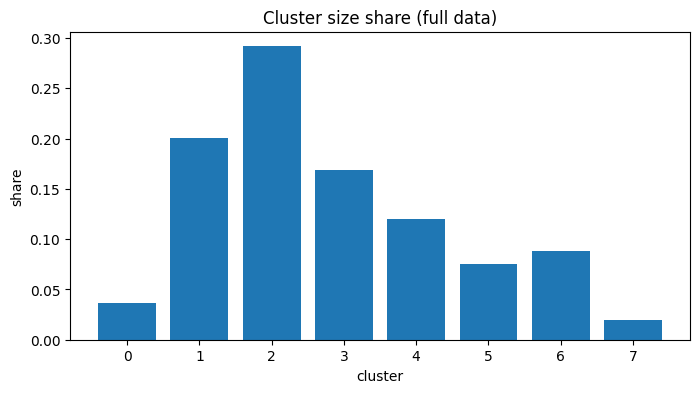

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,word_per_sec,sentiment
cluster,,,,,,,,,,,,
0,0.614571,0.686559,-6.930968,0.074638,0.414562,0.009967,0.332544,0.645158,124.414001,215803.648164,1.311142,0.199554
1,0.562782,0.486803,-9.746329,0.055090,0.445797,0.059258,0.197780,0.463524,116.997985,233939.084719,1.132069,0.559805
2,0.587341,0.781090,-6.100827,0.064701,0.113802,0.045976,0.213936,0.603506,126.062374,224077.738956,1.215607,0.233803
3,0.395960,0.852178,-5.891957,0.088171,0.043480,0.248781,0.270315,0.303019,131.163422,274458.148645,0.757122,-0.378360
4,0.468594,0.302106,-12.914550,0.044789,0.733040,0.092936,0.177017,0.311314,111.647223,237059.963624,0.726757,0.147597
5,0.633519,0.676361,-6.873282,0.080776,0.328681,0.018217,0.206191,0.655729,122.242507,227115.340433,1.285266,-0.406621
6,0.703457,0.675575,-7.082031,0.258090,0.202080,0.010272,0.219070,0.543317,118.471792,202457.037723,2.932735,-0.191800
7,0.593385,0.598149,-8.419081,0.099185,0.384927,0.042893,0.225833,0.514381,119.187236,224695.775563,1.365206,-0.132733


Saved cluster summaries to Drive.


In [25]:
from time import time

# --- ADD: make usecols safe (drops missing like 'popularity') ---
cols_in_file = pd.read_csv(FILE_MAIN, nrows=0).columns.tolist()
USECOLS_FULL_OK = [c for c in USECOLS_FULL if c in cols_in_file]
missing = sorted(set(USECOLS_FULL) - set(USECOLS_FULL_OK))
if missing:
    print("Dropping missing columns from USECOLS_FULL:", missing)
# ---------------------------------------------------------------

OUT_PATH = os.path.join(DATA_DIR, "predictions.csv")
print("Will write to:", OUT_PATH)

k = best_k
counts = np.zeros(k, dtype=np.int64)
sum_audio = np.zeros((k, len(AUDIO_MEAN_COLS)), dtype=np.float64)

t0 = time()
rows_done = 0

with open(OUT_PATH, "w", encoding="utf-8") as f:
    f.write("id,cluster\n")

for chunk in pd.read_csv(
    FILE_MAIN,
    usecols=USECOLS_FULL_OK,   # <-- ONLY CHANGE
    dtype=DTYPE_NUM,
    chunksize=CHUNK_SIZE
):
    # Add derived text numeric features once per chunk (avoids KeyError in downstream code)
    chunk = add_text_numeric_features(chunk)

    X_chunk = build_feature_matrix(
        chunk, audio_pack, text_pack,
        audio_weight=AUDIO_WEIGHT, text_weight=TEXT_WEIGHT, l2_normalize=L2_NORMALIZE
    )
    labels = kmeans_model.predict(X_chunk).astype(np.int32)

    out_chunk = pd.DataFrame({
        "id": chunk["id"].astype(str).values,
        "cluster": labels
    })
    out_chunk.to_csv(OUT_PATH, mode="a", header=False, index=False)

    num = audio_pack["imp_num"].transform(chunk[AUDIO_MEAN_COLS]).astype(np.float64)
    counts += np.bincount(labels, minlength=k)
    np.add.at(sum_audio, labels, num)

    rows_done += len(chunk)
    if rows_done % (CHUNK_SIZE*4) == 0:
        print("Processed rows:", rows_done)

t_sec = round(time()-t0, 2)
print("Done. rows =", rows_done, "| time(sec) =", t_sec)

cluster_sizes = pd.Series(counts, index=range(k), name="count").sort_index()
display(cluster_sizes)

share = cluster_sizes / cluster_sizes.sum()
plt.figure(figsize=(8,4))
plt.bar(share.index.astype(str), share.values)
plt.title("Cluster size share (full data)")
plt.xlabel("cluster")
plt.ylabel("share")
plt.show()

audio_means = pd.DataFrame(sum_audio / np.maximum(counts.reshape(-1,1), 1), columns=AUDIO_MEAN_COLS)
audio_means["cluster"] = range(k)
audio_means = audio_means.set_index("cluster")
display(audio_means)

cluster_sizes.to_csv(os.path.join(DATA_DIR, f"cluster_sizes_k{best_k}_{CACHE_TAG}.csv"))
audio_means.to_csv(os.path.join(DATA_DIR, f"cluster_audio_means_k{best_k}_{CACHE_TAG}.csv"))
print("Saved cluster summaries to Drive.")


# Interpret Clusters

Use full-data audio means, sample songs, and sample lyric keywords.

Why the 2-cluster heatmap looks odd:

With k = 2, there are only two rows → looks like two color blocks.

Raw units (e.g., duration_ms) distort the scale.

Fix:

Use z-score heatmap (based on sample mean/std).

If k = 2, add a difference bar chart (cluster1 − cluster0).


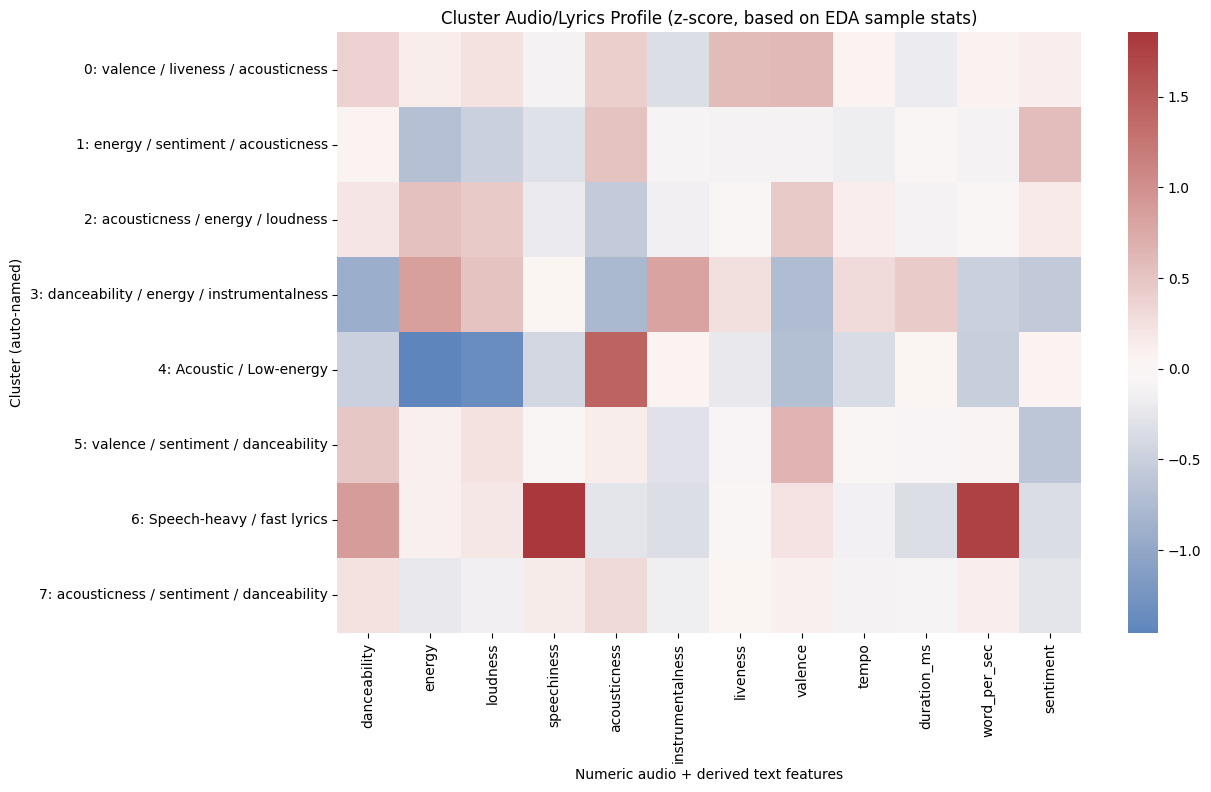

,cluster,cluster_name,count_sample,count_full,share_full,share_sample
0,0,valence / liveness / acousticness,718,34769,0.036395,0.03590
1,1,energy / sentiment / acousticness,4032,191420,0.200373,0.20160
2,2,acousticness / energy / loudness,5831,278604,0.291634,0.29155
3,3,danceability / energy / instrumentalness,3325,161156,0.168693,0.16625
4,4,Acoustic / Low-energy,2382,114717,0.120082,0.11910
5,5,valence / sentiment / danceability,1498,72073,0.075444,0.07490
6,6,Speech-heavy / fast lyrics,1801,84273,0.088214,0.09005
7,7,acousticness / sentiment / danceability,413,18308,0.019164,0.02065


Saved cluster name map CSV: /content/drive/Shareddrives/ML1/FinalProject/Code/cluster_names_k8_v6_sup_wps.csv
Representative songs per cluster (closest to centroid) — sample view

=== Cluster 0 | valence / liveness / acousticness | sample size=718 ===


,id,name,artist_main,dist_to_center,cluster_name
13815,1Dn34cKUcB2GyiwLB6Dmay,Se Não For Pra Te Amar,Mulheres Perdidas,0.458414,valence / liveness / acousticness
9551,174S4zGFfw7tCzXni3x4qm,Loucura do Seu Coração,Sorriso Maroto,0.461443,valence / liveness / acousticness
9586,4mii3XbdNXJ1xAxyErj6sq,Nossa Canção,Pablo,0.463594,valence / liveness / acousticness
12992,73oASjvTO8lt3LSa8ApVMl,Alto Lá,Zeca Pagodinho,0.490458,valence / liveness / acousticness
8512,3SyTYQvg7Z7SQciGQnq7ru,Linguinha - Ao Vivo,Os Barões Da Pisadinha,0.494795,valence / liveness / acousticness
19915,6LhSG6VVRsMMwRrZHJvtoC,Leão Domado,Chico Rey & Paraná,0.496148,valence / liveness / acousticness
4952,21CkdN6hCwVc7wo3aT5DtZ,Faxina - Ao Vivo,Fred & Gustavo,0.496965,valence / liveness / acousticness
7858,1kTQQY4yYBDYkGVlJaBA2Q,Coração Teimoso,Aviões do Forró,0.501156,valence / liveness / acousticness
9028,4jSnDdlp89RGYD5m7hwRge,Sem Você Tá Foda,Mc Roginho;Raphaela Santos,0.502912,valence / liveness / acousticness
83,1LEPxPel74yMcONpRQNHi8,Juro Que Eu Te Amei - Ao Vivo,Forrozão Baby Som,0.504182,valence / liveness / acousticness



=== Cluster 1 | energy / sentiment / acousticness | sample size=4032 ===


,id,name,artist_main,dist_to_center,cluster_name
2743,0KD48mOvrHWdbIIbiXQq0D,Ton of Joy,Otis Redding,0.906754,energy / sentiment / acousticness
17382,6U9QQlA8x0lLpsQJHhMfxl,Love Lifted Me,Kenny Rogers,0.908383,energy / sentiment / acousticness
19826,3YqwL6xaDNIV5OUlBmxzPR,Love Is Not A Romantic Song,my little airport,0.913548,energy / sentiment / acousticness
2457,5HwdajampSCq4Jf7SmBFzJ,Love Hurts,Roy Orbison,0.913691,energy / sentiment / acousticness
185,1bZdOnI0GIcB2xqQqQH7DY,Love Me Tender,Elvis Presley,0.914744,energy / sentiment / acousticness
4767,2SjMzNaZj3l3qQXtGha5ok,Pure Love (Single Version),Betty Wright,0.917653,energy / sentiment / acousticness
8134,6MC85zBk1dQqnywRDdzy7h,I Love Paris,Screamin' Jay Hawkins,0.917903,energy / sentiment / acousticness
18715,387QFDTQH0gmsHdzPQNLNb,別提你的心,Jacky Cheung,0.918111,energy / sentiment / acousticness
18546,3BhImmLpDfBNVz3Chfzopd,The Islands (Interlude),Janet Jackson,0.918267,energy / sentiment / acousticness
14113,46tNGUHSlfJUip1ZMaDLzw,Queen Majesty,The Techniques,0.919787,energy / sentiment / acousticness


...


=== Cluster 6 | Speech-heavy / fast lyrics | sample size=1801 ===


,id,name,artist_main,dist_to_center,cluster_name
17310,1EfJ3dY940sCY9DbgxZIPI,Get It Up,Sticky Fingaz,0.716608,Speech-heavy / fast lyrics
15185,7BCq3pUvTqJMvBzUmhcexK,Thotiana (REMIX feat. YG),Blueface,0.726428,Speech-heavy / fast lyrics
16914,59uDgG3CjoozlbMJy7n9CZ,Get in Touch With Us (feat. Styles P. of the Lox),Lil' Kim,0.732177,Speech-heavy / fast lyrics
14557,2DiFJhH9ZMOfhBiQPgj2bd,IN A MIN,Juicy J,0.732566,Speech-heavy / fast lyrics
3943,0erZQAD6lAJfdqwJDg9mlc,Oops!,Bill Cosby,0.737417,Speech-heavy / fast lyrics
11640,5ZWNnO9MyPfGrUHiGWHESB,Pressurelicious (feat. Future),Megan Thee Stallion,0.737776,Speech-heavy / fast lyrics
574,6mcu7D7QuABVwUGDwovOEh,If I Can't,50 Cent,0.739329,Speech-heavy / fast lyrics
17722,2agBuyTLCHxi0VvsBlueRw,Fallen Blixkys,22Gz,0.740873,Speech-heavy / fast lyrics
11377,6qQi0SlfZ07O3RIuIKCjNB,Beef (feat. Mobb Deep),The Notorious B.I.G.,0.741799,Speech-heavy / fast lyrics
1816,2nKYHpmwjLaEOXS3o7QMiz,Baby,Quality Control,0.741975,Speech-heavy / fast lyrics



=== Cluster 7 | acousticness / sentiment / danceability | sample size=413 ===


,id,name,artist_main,dist_to_center,cluster_name
14415,5jUgF1vpjj7bSnkiYv5Mko,Violon,VILK,0.292759,acousticness / sentiment / danceability
16060,3dlzrEr7Lx3FbAcRNjxyCQ,Comme ils disent,Dany Brillant,0.305733,acousticness / sentiment / danceability
3757,4mtYHRJeM3JLmqt3E299wQ,Belle Montréalaise,Sam Harvey,0.310484,acousticness / sentiment / danceability
6219,5sK9LwsIMdqREg9EvM8Stf,Ma Génération,Lounaa,0.324238,acousticness / sentiment / danceability
17460,2F73WWfXktP6v1B6PumWVW,La Tribu de Dana,QW4RTZ,0.327235,acousticness / sentiment / danceability
11958,0hTdrLQ3NYQ384J66Xh0BJ,Courchevel,Florent Marchet,0.327672,acousticness / sentiment / danceability
33,1yakLiNCGuUe1EgIHSFiva,Chanson Triste,Nakk Mendosa,0.330252,acousticness / sentiment / danceability
17744,2TgagJJfGiRdhNBTNXDFEM,Tu oublieras mon nom,Cœur De Pirate,0.335617,acousticness / sentiment / danceability
4839,6Dg8gVIDAru7buEGH1Xb6g,Amoureuse,Clio,0.337039,acousticness / sentiment / danceability
18929,5d6OfV6QuZFkapwMCqRIjw,La saison des fêtes,Various Artists,0.338414,acousticness / sentiment / danceability


Saved representative songs CSV to Drive.

Top distinctive terms for cluster 0 | valence / liveness / acousticness:
[('não', np.float32(0.15801887)), ('que', np.float32(0.13346809)), ('pra', np.float32(0.10698234)), ('você', np.float32(0.10633273)), ('meu', np.float32(0.09305486)), ('vai', np.float32(0.054993562)), ('amor', np.float32(0.054028794)), ('com', np.float32(0.05398356)), ('mais', np.float32(0.051305294)), ('minha', np.float32(0.050719187)), ('vou', np.float32(0.046096746)), ('seu', np.float32(0.041866537)), ('uma', np.float32(0.040297676)), ('mas', np.float32(0.03809342)), ('quero', np.float32(0.03770201))]

Top distinctive terms for cluster 1 | energy / sentiment / acousticness:
[('love', np.float32(0.07110892)), ('just', np.float32(0.023470486)), ('know', np.float32(0.021669725)), ('say', np.float32(0.0149646755)), ('time', np.float32(0.012692386)), ('heart', np.float32(0.011840267)), ('way', np.float32(0.011405382)), ('want', np.float32(0.010705896)), ('day', np.float32(0.

In [26]:
# ===== 9A) Cluster profiles (z-scores) =====
# Compare each full-data cluster mean to the global mean/std measured on the EDA sample.
# This makes features comparable even though they are in different units (tempo vs loudness vs duration, etc.).

df_eda = add_text_numeric_features(df_eda)
eda_num = audio_pack["imp_num"].transform(df_eda[AUDIO_MEAN_COLS]).astype(np.float64)
global_mean = eda_num.mean(axis=0)
global_std  = eda_num.std(axis=0) + 1e-9

z = (audio_means.values - global_mean.reshape(1,-1)) / global_std.reshape(1,-1)
audio_z = pd.DataFrame(z, index=audio_means.index, columns=AUDIO_MEAN_COLS)

# ===== 9B) Auto-name clusters from their standardized profiles =====
def auto_cluster_name(zrow: pd.Series) -> str:
    """Heuristic cluster label based on high/low z-score features.

    Important: these are *descriptive attribute names* (e.g., "High-energy / Danceable"),
    not ground-truth genres.
    """
    tags = []

    # Instrumentation / texture
    if zrow.get("instrumentalness", 0) > 0.9:
        tags.append("Instrumental")
    if zrow.get("acousticness", 0) > 0.9:
        tags.append("Acoustic")
    if zrow.get("liveness", 0) > 0.8:
        tags.append("Live-sounding")

    # Energy / dance
    if (zrow.get("energy", 0) > 0.9) or (zrow.get("loudness", 0) > 0.9):
        tags.append("High-energy")
    elif (zrow.get("energy", 0) < -0.9) and (zrow.get("acousticness", 0) > 0):
        tags.append("Low-energy")

    if zrow.get("danceability", 0) > 0.9:
        tags.append("Danceable")

    # Vocal density / lyrical speed
    if (zrow.get("speechiness", 0) > 0.9) or (zrow.get("word_per_sec", 0) > 0.9):
        tags.append("Speech-heavy / fast lyrics")

    # Tempo
    if zrow.get("tempo", 0) > 0.9:
        tags.append("Fast tempo")
    elif zrow.get("tempo", 0) < -0.9:
        tags.append("Slow tempo")

    # Mood proxy: valence + sentiment
    val = float(zrow.get("valence", 0))
    sent = float(zrow.get("sentiment", 0))
    if (val > 0.8) and (sent > 0.1):
        tags.append("Positive mood")
    elif (val < -0.8) and (sent < -0.1):
        tags.append("Darker mood")

    # Duration (optional)
    if zrow.get("duration_ms", 0) > 1.0:
        tags.append("Long tracks")
    elif zrow.get("duration_ms", 0) < -1.0:
        tags.append("Short tracks")

    if len(tags) == 0:
        top = zrow.abs().sort_values(ascending=False).index[:3].tolist()
        tags = [t.replace("_", " ") for t in top]

    # De-duplicate while preserving order
    seen = set()
    tags2 = []
    for t in tags:
        if t not in seen:
            tags2.append(t)
            seen.add(t)

    return " / ".join(tags2[:3])

cluster_name_map = {int(c): auto_cluster_name(audio_z.loc[c]) for c in audio_z.index}

# ===== 9C) Heatmap (with names) =====
audio_z_named = audio_z.copy()
audio_z_named.index = [f"{int(c)}: {cluster_name_map.get(int(c), '')}" for c in audio_z_named.index]

plt.figure(figsize=(12, 0.6*len(audio_z_named)+3))
sns.heatmap(audio_z_named, center=0, cmap="vlag")
plt.title("Cluster Audio/Lyrics Profile (z-score, based on EDA sample stats)")
plt.xlabel("Numeric audio + derived text features")
plt.ylabel("Cluster (auto-named)")
plt.show()

# ===== 9D) Representative songs per cluster (sample view) =====
X_eda = build_feature_matrix(
    df_eda, audio_pack, text_pack,
    audio_weight=AUDIO_WEIGHT, text_weight=TEXT_WEIGHT, l2_normalize=L2_NORMALIZE
)
labels_eda = kmeans_model.predict(X_eda)
centers = kmeans_model.cluster_centers_.astype(np.float32)

dists = np.linalg.norm(X_eda - centers[labels_eda], axis=1)

df_repr = df_eda[["id","name","artist_main","lyrics"]].copy()
df_repr["cluster"] = labels_eda
df_repr["cluster_name"] = df_repr["cluster"].map(cluster_name_map)
df_repr["dist_to_center"] = dists

# Cluster size summary (full data if available; otherwise sample)
count_sample = pd.Series(np.bincount(labels_eda, minlength=best_k), index=range(best_k), name="count_sample")
if "cluster_sizes" in globals():
    count_full = cluster_sizes.reindex(range(best_k)).fillna(0).astype(int)
else:
    count_full = None

cluster_name_df = pd.DataFrame({
    "cluster": range(best_k),
    "cluster_name": [cluster_name_map.get(i, f"Cluster {i}") for i in range(best_k)],
    "count_sample": count_sample.values
})
if count_full is not None:
    cluster_name_df["count_full"] = count_full.values
    cluster_name_df["share_full"] = cluster_name_df["count_full"] / cluster_name_df["count_full"].sum()
cluster_name_df["share_sample"] = cluster_name_df["count_sample"] / cluster_name_df["count_sample"].sum()

display(cluster_name_df)

cluster_name_path = os.path.join(DATA_DIR, f"cluster_names_k{best_k}_{CACHE_TAG}.csv")
cluster_name_df.to_csv(cluster_name_path, index=False)
print("Saved cluster name map CSV:", cluster_name_path)

print("Representative songs per cluster (closest to centroid) — sample view")
repr_rows = []
for c in sorted(df_repr["cluster"].unique()):
    cname = cluster_name_map.get(int(c), "")
    sub = df_repr[df_repr["cluster"]==c].nsmallest(10, "dist_to_center")[["id","name","artist_main","dist_to_center","cluster_name"]]
    print(f"\n=== Cluster {c} | {cname} | sample size={int((df_repr['cluster']==c).sum())} ===")
    display(sub)
    tmp = sub.copy()
    tmp["cluster"] = int(c)
    repr_rows.append(tmp)

repr_out = pd.concat(repr_rows, ignore_index=True)
repr_out.to_csv(os.path.join(DATA_DIR, f"representative_songs_sample_k{best_k}_{CACHE_TAG}.csv"), index=False)
print("Saved representative songs CSV to Drive.")

# ===== 9E) Distinctive lyric terms per cluster (sample) =====
tfidf = text_pack["tfidf"]
terms = np.array(tfidf.get_feature_names_out())

X_tfidf_eda = tfidf.transform(df_eda["lyrics"].fillna(""))
global_mean_vec = np.asarray(X_tfidf_eda.mean(axis=0)).ravel()

def top_distinct_terms(cluster_id, top_n=15):
    idx = (labels_eda == cluster_id)
    if idx.sum() == 0:
        return []
    mean_vec = np.asarray(X_tfidf_eda[idx].mean(axis=0)).ravel()
    diff = mean_vec - global_mean_vec
    pos = diff > 0
    if not pos.any():
        top_idx = diff.argsort()[::-1][:top_n]
        return list(zip(terms[top_idx], diff[top_idx]))
    diff2 = diff.copy()
    diff2[~pos] = -np.inf
    top_idx = np.argsort(diff2)[::-1][:top_n]
    return list(zip(terms[top_idx], diff[top_idx]))

all_terms_rows = []
for c in sorted(np.unique(labels_eda)):
    cname = cluster_name_map.get(int(c), "")
    top_terms = top_distinct_terms(c, top_n=15)
    print(f"\nTop distinctive terms for cluster {c} | {cname}:")
    print(top_terms)
    for t, score in top_terms:
        all_terms_rows.append({"cluster": int(c), "cluster_name": cname, "term": t, "score": float(score)})

pd.DataFrame(all_terms_rows).to_csv(os.path.join(DATA_DIR, f"distinctive_terms_sample_k{best_k}_{CACHE_TAG}.csv"), index=False)
print("Saved distinctive terms CSV to Drive.")

# DBSCAN or Hierarchical

Other algorithms should also be adjusted.

DBSCAN: Slow for high-dimensional, large datasets; sensitive to eps and min_samples.

Hierarchical: Higher complexity; not practical on full data.

So run them only on a sample (e.g., 10k–20k) to compare different unsupervised methods.

In [27]:
RUN_DBSCAN = True
RUN_HIER   = True

N_SECOND_MODEL = min(15_000, len(df_base))
df_m2 = df_base.sample(n=N_SECOND_MODEL, random_state=RANDOM_STATE+3).reset_index(drop=True)

X_m2 = build_feature_matrix(
    df_m2, audio_pack, text_pack,
    audio_weight=AUDIO_WEIGHT, text_weight=TEXT_WEIGHT, l2_normalize=L2_NORMALIZE
)

import umap
reducer = umap.UMAP(n_components=10, random_state=RANDOM_STATE)
X_m2_umap = reducer.fit_transform(X_m2)

labels_k2 = kmeans_model.predict(X_m2).astype(int)

if RUN_DBSCAN:
    db = DBSCAN(eps=0.6, min_samples=10)
    labels_db = db.fit_predict(X_m2_umap)
    df_m2["cluster_dbscan"] = labels_db

    n_noise = int((labels_db == -1).sum())
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    print("DBSCAN clusters:", n_clusters, "| noise points:", n_noise, f"({n_noise/len(labels_db):.1%})")

    if n_clusters >= 2:

        mask = labels_db != -1
        sil = silhouette_score(X_m2_umap[mask], labels_db[mask])
        print("DBSCAN silhouette (non-noise only):", float(sil))

    from sklearn.metrics import adjusted_rand_score
    print("ARI (KMeans vs DBSCAN, treating noise as a label):", float(adjusted_rand_score(labels_k2, labels_db)))

if RUN_HIER:
    n_h = min(8_000, len(df_m2))
    X_h = X_m2_umap[:n_h]
    hier = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
    labels_h = hier.fit_predict(X_h)
    print("Hierarchical silhouette (sample):", float(silhouette_score(X_h, labels_h)))

    from sklearn.metrics import adjusted_rand_score
    print("ARI (KMeans vs Hierarchical on same subset):", float(adjusted_rand_score(labels_k2[:n_h], labels_h)))


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


DBSCAN clusters: 48 | noise points: 82 (0.5%)
DBSCAN silhouette (non-noise only): 0.20799289643764496
ARI (KMeans vs DBSCAN, treating noise as a label): 0.07171702069706135
Hierarchical silhouette (sample): 0.29713335633277893
ARI (KMeans vs Hierarchical on same subset): 0.17477945596372324


In [28]:
import umap

reducer_2d = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_umap2 = reducer_2d.fit_transform(X_m2)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [29]:

plot_df = pd.DataFrame({
    "umap1": X_umap2[:,0],
    "umap2": X_umap2[:,1],
    "kmeans": labels_k2
})

if RUN_DBSCAN:
    plot_df["dbscan"] = labels_db

if RUN_HIER:
    plot_df["hier"] = None
    plot_df.loc[:n_h-1, "hier"] = labels_h

plot_df.head()

,umap1,umap2,kmeans,dbscan,hier
0,-5.337461,2.695328,2,0,1
1,-4.114513,7.861699,2,1,1
2,-3.596478,1.889150,3,2,1
3,-2.034711,5.229624,1,3,3
4,-1.092780,5.672580,2,4,1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# -------------------------------------------------
# 1) Build a fresh 2D UMAP embedding for plotting
# -------------------------------------------------
reducer_2d = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_umap2 = reducer_2d.fit_transform(X_m2)

plot_df = pd.DataFrame({
    "umap1": X_umap2[:, 0],
    "umap2": X_umap2[:, 1],
    "kmeans": labels_k2
})

if RUN_DBSCAN:
    plot_df["dbscan"] = labels_db

if RUN_HIER:
    plot_df["hier"] = pd.NA
    plot_df.loc[:n_h-1, "hier"] = labels_h

# -------------------------------------------------
# 2) Clean plotting theme
# -------------------------------------------------
sns.set_theme(style="white", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -------------------------
# Panel 1: KMeans
# -------------------------
sns.scatterplot(
    data=plot_df,
    x="umap1", y="umap2",
    hue="kmeans",
    palette="tab10",
    s=10,
    alpha=0.75,
    linewidth=0,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("K-Means", fontsize=14)
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# -------------------------
# Panel 2: DBSCAN
# -------------------------
if RUN_DBSCAN:
    # separate noise for cleaner plotting
    plot_db = plot_df.copy()
    noise_mask = plot_db["dbscan"] == -1
    cluster_mask = ~noise_mask

    # clustered points
    sns.scatterplot(
        data=plot_db.loc[cluster_mask],
        x="umap1", y="umap2",
        hue="dbscan",
        palette="tab20",
        s=10,
        alpha=0.75,
        linewidth=0,
        legend=False,
        ax=axes[1]
    )

    # noise points in light gray
    if noise_mask.any():
        axes[1].scatter(
            plot_db.loc[noise_mask, "umap1"],
            plot_db.loc[noise_mask, "umap2"],
            s=8,
            alpha=0.4,
            c="lightgray",
            label="noise"
        )

    axes[1].set_title("DBSCAN", fontsize=14)
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")
else:
    axes[1].axis("off")

# -------------------------
# Panel 3: Hierarchical
# -------------------------
if RUN_HIER:
    plot_h = plot_df.iloc[:n_h].copy()

    sns.scatterplot(
        data=plot_h,
        x="umap1", y="umap2",
        hue="hier",
        palette="tab10",
        s=10,
        alpha=0.75,
        linewidth=0,
        legend=False,
        ax=axes[2]
    )
    axes[2].set_title("Hierarchical (Ward)", fontsize=14)
    axes[2].set_xlabel("UMAP 1")
    axes[2].set_ylabel("UMAP 2")
else:
    axes[2].axis("off")

# -------------------------------------------------
# 3) Remove clutter and standardize axes appearance
# -------------------------------------------------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

plt.suptitle("2D UMAP Comparison Across Clustering Methods", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Visualization (on Sample): PCA / UMAP 2D

These plots reduce high-dimensional features to 2D to help visually check whether clusters separate.

Note: 2D visualization does not represent the true high-dimensional structure; it is only for interpretation.

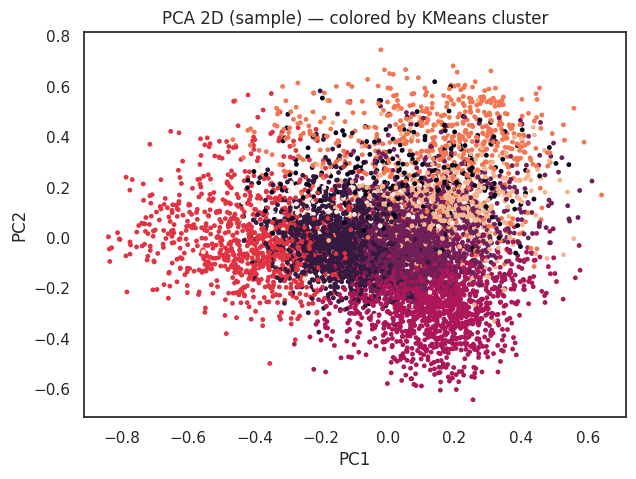

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


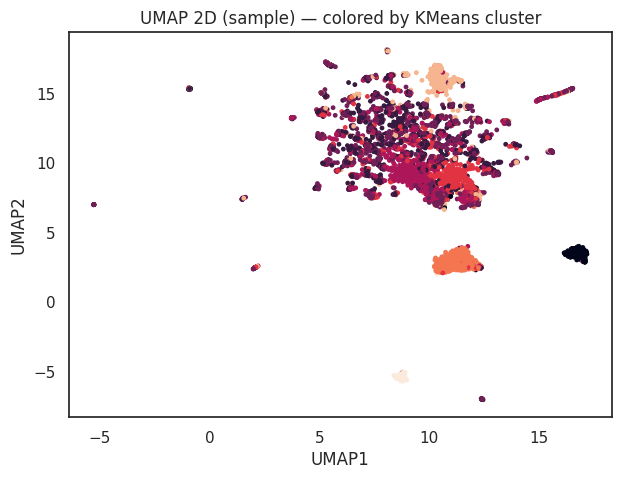

In [31]:
import umap

N_PLOT = min(8000, len(df_eda))
df_plot = df_eda.sample(n=N_PLOT, random_state=RANDOM_STATE+10).reset_index(drop=True)

X_plot = build_feature_matrix(
    df_plot, audio_pack, text_pack,
    audio_weight=AUDIO_WEIGHT, text_weight=TEXT_WEIGHT, l2_normalize=L2_NORMALIZE
)
labels_plot = kmeans_model.predict(X_plot)

# PCA 2D
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_plot)

plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_plot, s=6)
plt.title("PCA 2D (sample) — colored by KMeans cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

reducer2 = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_umap2 = reducer2.fit_transform(X_plot)

plt.figure(figsize=(7,5))
plt.scatter(X_umap2[:,0], X_umap2[:,1], c=labels_plot, s=6)
plt.title("UMAP 2D (sample) — colored by KMeans cluster")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


## External Validation (Optional): Use SpotifyFeatures Genre / Popularity

This is not supervised learning—genre is not used as a training label.

If matched with external genre / popularity, you can check:

Whether some genres concentrate in certain clusters (cluster as a genre proxy).

Whether popularity differs systematically across clusters.


In [43]:
if os.path.exists(FILE_SPOTIFY):
    sp = pd.read_csv(FILE_SPOTIFY)
    sp.columns = [c.lower() for c in sp.columns]
    if "track_id" in sp.columns and "id" not in sp.columns:
        sp = sp.rename(columns={"track_id":"id"})
    else:
        sp["id"] = sp["id"].astype(str)

        tmp = df_eda[["id"]].copy()
        tmp["id"] = tmp["id"].astype(str)
        tmp["cluster"] = labels_eda

        keep_cols = ["id"]
        if "genre" in sp.columns: keep_cols.append("genre")
        if "popularity" in sp.columns: keep_cols.append("popularity")

        merged = tmp.merge(sp[keep_cols], on="id", how="inner")
        print("Matched rows with SpotifyFeatures:", merged.shape)

        if "genre" in merged.columns:
            # cluster -> top genres
            ct = pd.crosstab(merged["cluster"], merged["genre"])
            share = ct.div(ct.sum(axis=1), axis=0)

            summary = []
            for c in sorted(merged["cluster"].unique()):
                s = share.loc[c].sort_values(ascending=False)
                top_genre = s.index[0]
                top_share = float(s.iloc[0])
                summary.append({
                    "cluster": int(c),
                    "matched_n": int(ct.loc[c].sum()),
                    "top_genre": str(top_genre),
                    "top_genre_share": top_share
                })

            genre_summary = pd.DataFrame(summary).sort_values("cluster")
            display(genre_summary)

            plt.figure(figsize=(8,4))
            plt.bar(genre_summary["cluster"].astype(str), genre_summary["top_genre_share"])
            plt.title("Cluster genre purity (top genre share) — matched subset")
            plt.xlabel("cluster")
            plt.ylabel("top genre share")
            plt.show()

        if "popularity" in merged.columns:
            pop = merged.groupby("cluster")["popularity"].mean().sort_index()
            print("Mean popularity by cluster (matched subset):")
            display(pop)

else:
    print("SpotifyFeatures.csv not found. Skip external validation.")


## Recommendation Demo (on Sample): Same-Cluster + Nearest Neighbors

For a simple content-based recommender in your proposal:
given a song, find its most similar songs in feature space, preferably within the same cluster.

Use a sample for the demo—the logic is enough for your report/presentation.


In [34]:
X_rec = normalize(X_eda)
nn = NearestNeighbors(n_neighbors=50, metric="cosine", algorithm="brute")
nn.fit(X_rec)

id2idx = {str(rid): i for i, rid in enumerate(df_eda["id"].astype(str).values)}

def recommend_by_id(song_id, top_n=10, same_cluster=True):
    song_id = str(song_id)
    if song_id not in id2idx:
        return pd.DataFrame({"error":[f"id {song_id} not found in sample"]})

    i = id2idx[song_id]
    base_cluster = int(labels_eda[i])

    distances, indices = nn.kneighbors(X_rec[i].reshape(1, -1), n_neighbors=50)
    indices = indices.ravel().tolist()
    distances = distances.ravel().tolist()

    recs = []
    for j, d in zip(indices, distances):
        if j == i:
            continue
        if same_cluster and int(labels_eda[j]) != base_cluster:
            continue
        recs.append({
            "id": str(df_eda.iloc[j]["id"]),
            "name": df_eda.iloc[j]["name"],
            "artist": df_eda.iloc[j]["artist_main"],
            "cluster": int(labels_eda[j]),
            "cosine_distance": float(d)
        })
        if len(recs) >= top_n:
            break

    return pd.DataFrame(recs)

example = df_eda.sample(1, random_state=RANDOM_STATE+123).iloc[0]
print("Query song:", example["id"], "|", example["name"], "|", example["artist_main"], "| cluster =", int(labels_eda[df_eda.index.get_loc(example.name)]))

display(recommend_by_id(example["id"], top_n=10, same_cluster=True))


Query song: 1TZEM9g07TvmhfrAddQJnQ | The Undertow | Big Something | cluster = 2


,id,name,artist,cluster,cosine_distance
0,3bEODEwML3ypgN8oJi3fHs,Closer,Manic Drive,2,0.392434
1,3JYaqoCPPStyaWX70701U4,Highway Crimes (feat. Accalia Snow),Moog,2,0.420281
2,6OlRnUa93tkUXDX8Ow3Bko,Higher Ground,Stevie Wonder,2,0.437376
3,479TxgywFgaMMDVyYsIFAt,We Are Fighters,Da Tweekaz,2,0.439173
4,1kIAQIDWsbJF0IjV8WHaR6,Crowd Control (Do What We Want),Sumo Cyco,2,0.456779
5,751BkT4b6LUb3QFM9zG8p7,Love Ballad,Tove Lo,2,0.469582
6,1GmQN5AYSmZFYTw10AfcLe,Tears Of Gold,David Bisbal,2,0.499335
7,0uJhueBXAS1Ppg2vTC2JVI,On Top of the World (Remix),Elevation Youth,2,0.501224
8,7oBiUeGDtMs57RBDpd4OVs,T-Shirt - Radio Killa Remix,Shontelle,2,0.501589
9,7EClrhvMSIq3yuHHphCkst,Fall In Love - Spotify Sessions Curated by Jim...,Phantogram,2,0.514807


## Clustering Model Comparison Summary (Sample Metrics + Visual Checks)

Because we do **not** have ground-truth labels for the clustering task, this section uses internal clustering metrics and interpretability checks.

Key metrics (rule of thumb):

- **Silhouette score** (range: -1 to 1): **higher is better**.
- **Davies–Bouldin index (DB)**: **lower is better**.
- **Calinski–Harabasz (CH)**: **higher is better**.

Caution: if different models use different embeddings (e.g., UMAP10D) and/or different sample sizes,
their scores are **not perfectly apples-to-apples**. We treat these numbers as supporting evidence together with
cluster interpretability, label stability, and computational feasibility (full-data labeling requirement).


In [35]:
rows = []

# -----------------------------
# KMeans (evaluated on X_eda = same feature space used for KMeans)
# -----------------------------
sil_k = float(silhouette_score(X_eda, labels_eda, sample_size=min(8000, len(X_eda)), random_state=RANDOM_STATE))
db_k  = float(davies_bouldin_score(X_eda, labels_eda))
ch_k  = float(calinski_harabasz_score(X_eda, labels_eda))
rows.append({
    "model": f"KMeans(k={best_k})",
    "n_points": int(len(X_eda)),
    "n_clusters": int(best_k),
    "noise_ratio": 0.0,
    "silhouette": sil_k,
    "davies_bouldin": db_k,
    "calinski_harabasz": ch_k
})

# -----------------------------
# DBSCAN (evaluated on X_m2_umap, excluding noise points)
# -----------------------------
try:
    if "labels_db" in globals():
        labels_db = np.asarray(labels_db)
        n_noise = int((labels_db == -1).sum())
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

        sil = dbi = chi = None
        if n_clusters >= 2:
            mask = labels_db != -1
            if mask.sum() >= 2:
                sil = float(silhouette_score(X_m2_umap[mask], labels_db[mask]))
                dbi = float(davies_bouldin_score(X_m2_umap[mask], labels_db[mask]))
                chi = float(calinski_harabasz_score(X_m2_umap[mask], labels_db[mask]))

        rows.append({
            "model": "DBSCAN(UMAP10D)",
            "n_points": int(len(labels_db)),
            "n_clusters": int(n_clusters),
            "noise_ratio": float(n_noise / len(labels_db)),
            "silhouette": sil,
            "davies_bouldin": dbi,
            "calinski_harabasz": chi
        })
except Exception as e:
    print("Skip DBSCAN summary:", e)

# -----------------------------
# Hierarchical (Ward) on UMAP10D subset X_h
# -----------------------------
try:
    if "labels_h" in globals():
        labels_h = np.asarray(labels_h)
        sil_h = db_h = ch_h = None
        if len(set(labels_h)) >= 2:
            sil_h = float(silhouette_score(X_h, labels_h))
            db_h  = float(davies_bouldin_score(X_h, labels_h))
            ch_h  = float(calinski_harabasz_score(X_h, labels_h))
        rows.append({
            "model": f"Hierarchical(k={best_k}, Ward, UMAP10D)",
            "n_points": int(len(labels_h)),
            "n_clusters": int(best_k),
            "noise_ratio": 0.0,
            "silhouette": sil_h,
            "davies_bouldin": db_h,
            "calinski_harabasz": ch_h
        })
except Exception as e:
    print("Skip Hier summary:", e)

summary_df = pd.DataFrame(rows)
display(summary_df)

summary_path = os.path.join(DATA_DIR, f"model_summary_{CACHE_TAG}_k{best_k}.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved model summary:", summary_path)

print("\nKey outputs on Drive:")
print(" - predictions.csv")
print(f" - cluster_sizes_k{best_k}_{CACHE_TAG}.csv")
print(f" - cluster_audio_means_k{best_k}_{CACHE_TAG}.csv")
print(f" - representative_songs_sample_k{best_k}_{CACHE_TAG}.csv")
print(f" - distinctive_terms_sample_k{best_k}_{CACHE_TAG}.csv")
print(f" - cluster_names_k{best_k}_{CACHE_TAG}.csv")

,model,n_points,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,KMeans(k=8),20000,8,0.000000,0.053194,4.537346,418.878531
1,DBSCAN(UMAP10D),15000,48,0.005467,0.207993,0.928663,1381.864296
2,"Hierarchical(k=8, Ward, UMAP10D)",8000,8,0.000000,0.297133,0.964481,2892.467991


Saved model summary: /content/drive/Shareddrives/ML1/FinalProject/Code/model_summary_v6_sup_wps_k8.csv

Key outputs on Drive:
 - predictions.csv
 - cluster_sizes_k8_v6_sup_wps.csv
 - cluster_audio_means_k8_v6_sup_wps.csv
 - representative_songs_sample_k8_v6_sup_wps.csv
 - distinctive_terms_sample_k8_v6_sup_wps.csv
 - cluster_names_k8_v6_sup_wps.csv


## Extra Visualizations for Clustering Model Comparison

These plots help compare clustering methods **at a glance** and explain the final choice in the report/presentation.


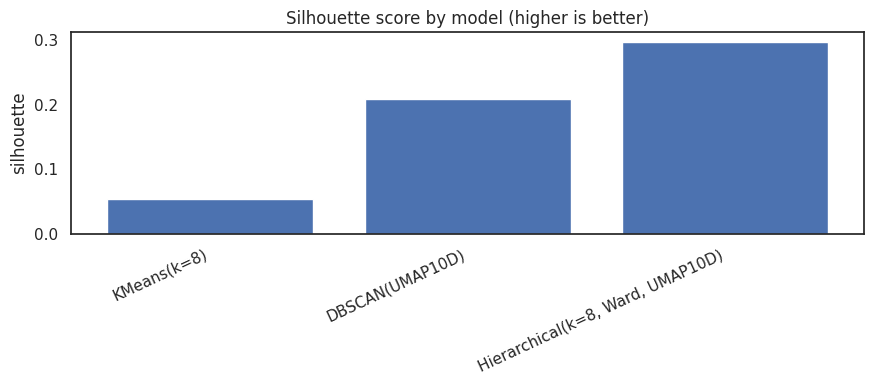

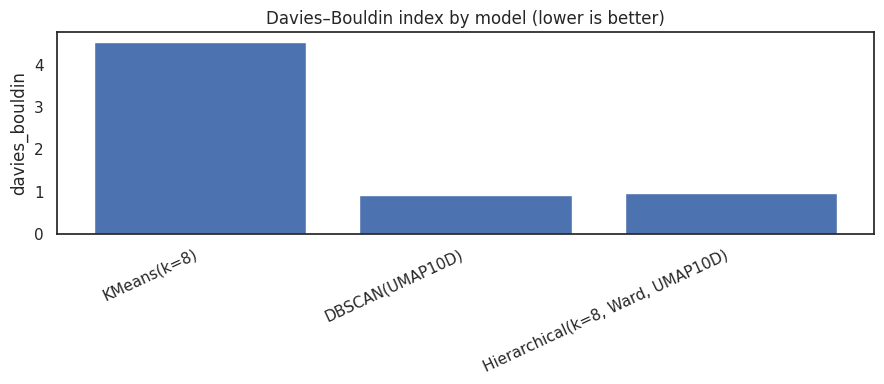

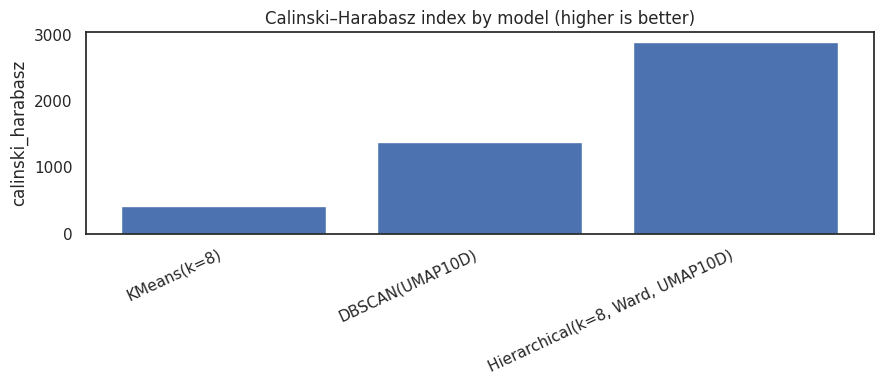

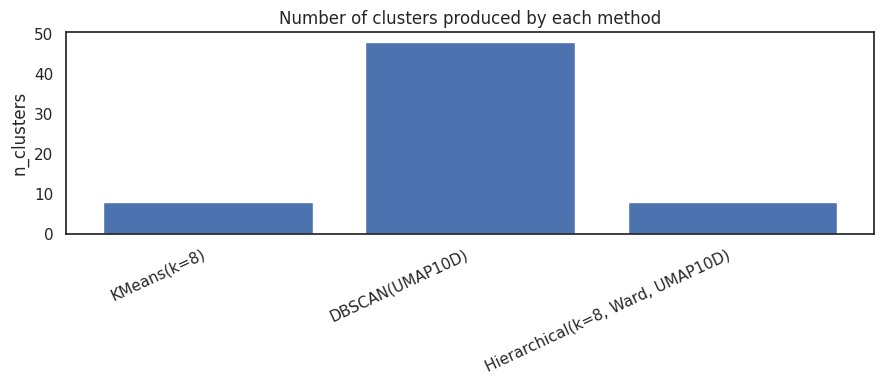

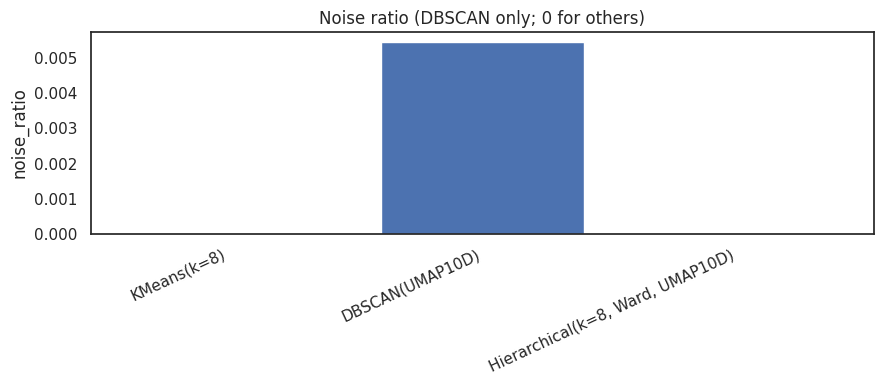

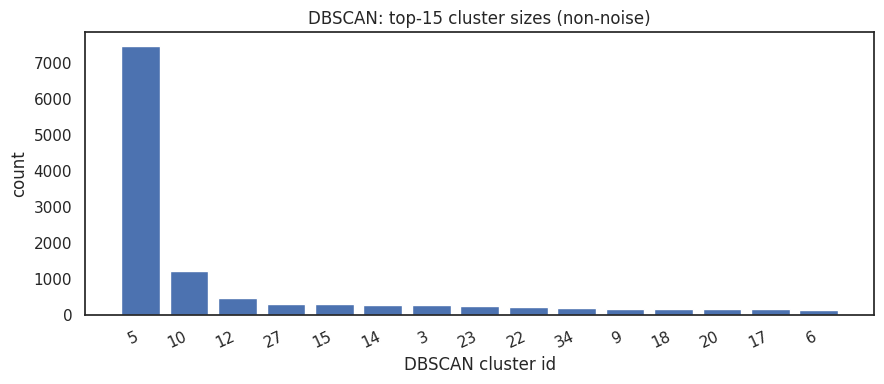

In [51]:

# ===== Model comparison visualizations =====
plot_df = summary_df.copy()

# Ensure numeric types
for col in ["silhouette","davies_bouldin","calinski_harabasz","noise_ratio","n_clusters","n_points"]:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

def simple_bar(metric, title, ylabel=None):
    dfm = plot_df[["model", metric]].dropna()
    if dfm.empty:
        print(f"[skip] {metric}: no values available")
        return
    plt.figure(figsize=(9, 4))
    plt.bar(dfm["model"], dfm[metric].values)
    plt.xticks(rotation=25, ha="right")
    plt.title(title)
    plt.ylabel(ylabel if ylabel else metric)
    plt.tight_layout()
    plt.show()

# Silhouette: higher is better
simple_bar("silhouette", "Silhouette score by model (higher is better)")

# Davies–Bouldin: lower is better (only models where it is defined)
simple_bar("davies_bouldin", "Davies–Bouldin index by model (lower is better)")

# Calinski–Harabasz: higher is better (only models where it is defined)
simple_bar("calinski_harabasz", "Calinski–Harabasz index by model (higher is better)")

# Cluster count + noise ratio
simple_bar("n_clusters", "Number of clusters produced by each method")
simple_bar("noise_ratio", "Noise ratio (DBSCAN only; 0 for others)")


# ===== DBSCAN cluster size distribution (top 15, excluding noise) =====
if "labels_db" in globals():
    s = pd.Series(labels_db)
    s = s[s != -1]  # exclude noise
    if len(s) > 0:
        top_sizes = s.value_counts().head(15)
        plt.figure(figsize=(9, 4))
        plt.bar(top_sizes.index.astype(str), top_sizes.values)
        plt.title("DBSCAN: top-15 cluster sizes (non-noise)")
        plt.xlabel("DBSCAN cluster id")
        plt.ylabel("count")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()

## Supervised Learning Extension: Genre Prediction on the Labeled Overlap Subset

The project is primarily unsupervised, but the overlap with `SpotifyFeatures.csv` gives us a labeled subset with genre information.  
To add one supervised learning model, we use **regularized multinomial Logistic Regression** on the same engineered feature space:

- audio features + `word_per_sec` + `sentiment`
- cyclical encoding for key
- TF-IDF → Truncated SVD lyric embedding
- optional L2 normalization

This is a good fit because the final feature vector is already standardized, dense, moderate-dimensional, and multiclass.  
We evaluate the supervised model on a held-out test split using **accuracy**, **balanced accuracy**, **macro-F1**, **weighted-F1**, and **top-3 accuracy**, plus a confusion matrix and per-genre F1 chart.


Genre counts used for supervised model:


,count
genre,
World,5000
Country,5000
Blues,5000
Reggaeton,5000
Reggae,5000
Dance,5000
Folk,5000
Ska,5000
Alternative,5000


Loaded supervised model: /content/drive/Shareddrives/ML1/FinalProject/Code/_ml_cache/genre_logreg_v6_sup_wps_sentiment.joblib
Held-out test metrics:


,model,task,n_train,n_test,n_classes,accuracy,balanced_accuracy,macro_f1,weighted_f1,top3_accuracy
0,Multinomial Logistic Regression,Predict top-10 Spotify genres,40000,10000,10,0.5908,0.5908,0.584221,0.584221,0.8532


,label,precision,recall,f1-score,support
0,Alternative,0.415230,0.2890,0.340802,1000.0000
1,Blues,0.487779,0.4590,0.472952,1000.0000
2,Country,0.505727,0.5740,0.537705,1000.0000
3,Dance,0.470942,0.4700,0.470470,1000.0000
4,Folk,0.504292,0.4700,0.486542,1000.0000
5,Hip-Hop,0.759682,0.7650,0.762332,1000.0000
6,Reggae,0.568465,0.5480,0.558045,1000.0000
7,Reggaeton,0.810026,0.9210,0.861956,1000.0000
8,Ska,0.552817,0.6280,0.588015,1000.0000
9,World,0.743833,0.7840,0.763389,1000.0000


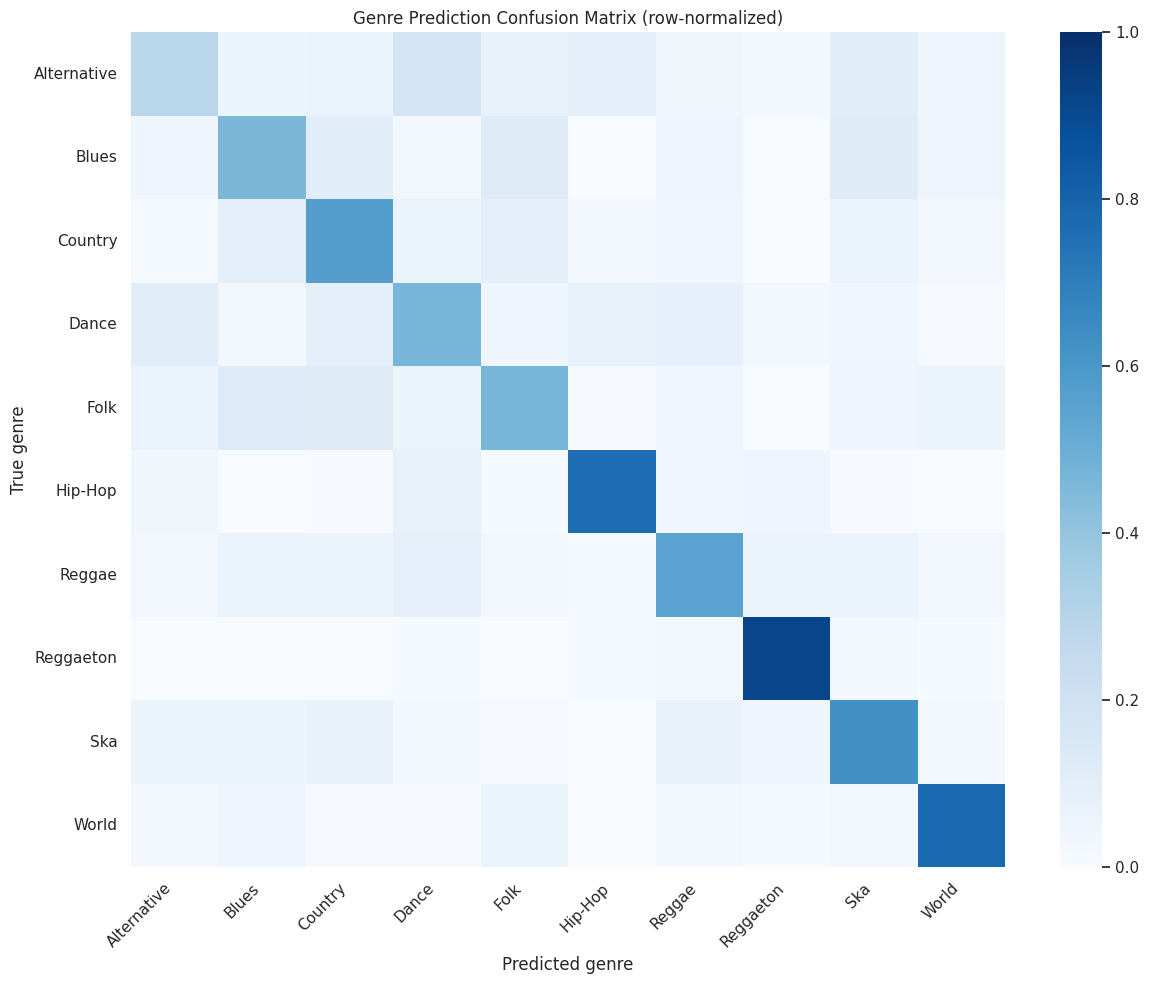

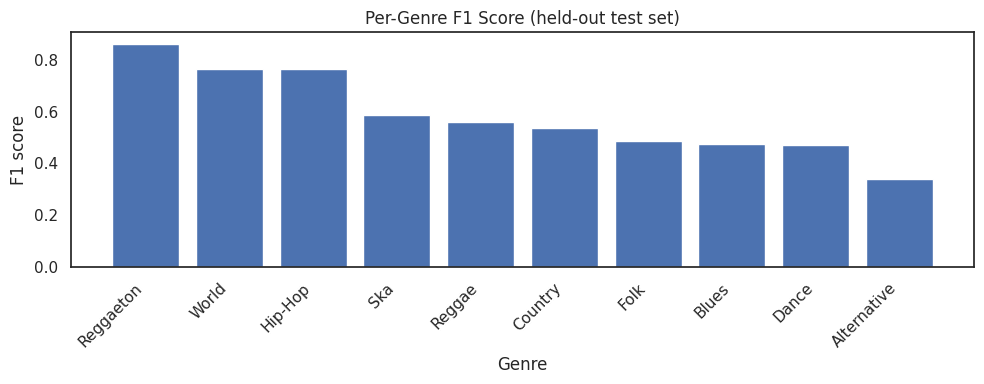

,feature,mean_abs_coef
10,word_per_sec,4.590687
0,danceability,4.450680
3,speechiness,3.391973
7,valence,2.837045
9,duration_ms,2.402483
4,acousticness,2.324202
1,energy,2.269981
2,loudness,2.096655
5,instrumentalness,1.643851
14,mode,1.109747


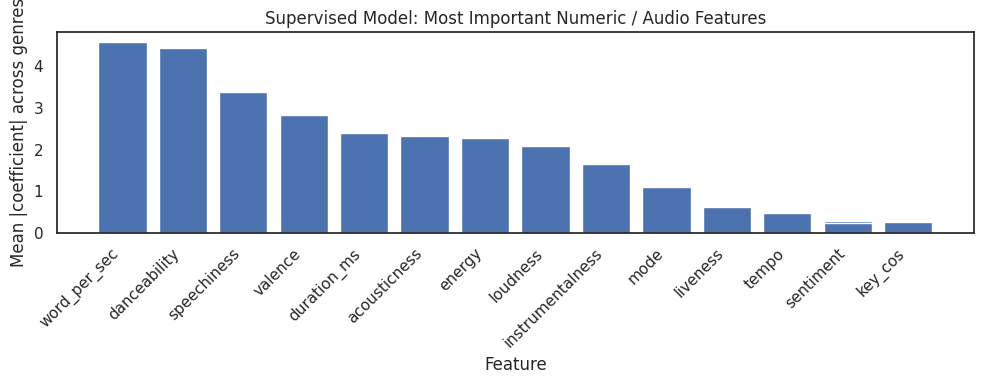

In [50]:
def build_feature_matrix(df, audio_pack, text_pack, audio_weight=1.0, text_weight=1.0,
                         extra_num_cols=None, extra_weight=1.0, l2_normalize=False):
    X_audio_scaled = make_audio_matrix(df, imp_audio=audio_pack, scaler_audio=audio_pack["scaler"], fit=False)
    X_text = transform_text_models(df["lyrics"], text_pack)

    parts = [X_audio_scaled * audio_weight, X_text * text_weight]

    if extra_num_cols is not None and len(extra_num_cols) > 0:
        X_extra = df[extra_num_cols].to_numpy(dtype=np.float32)
        parts.append(X_extra * extra_weight)

    X = np.hstack(parts).astype(np.float32)

    if l2_normalize:
        X = normalize(X).astype(np.float32)

    return X

from time import time

RUN_SUPERVISED = True

# Keep the supervised task manageable and meaningful.
SUP_TOP_N_GENRES = 10
SUP_MIN_GENRE_COUNT = 1000
SUP_MAX_PER_GENRE = 5000
SUP_TEST_SIZE = 0.20

# extra engineered numeric features to append to the matrix
EXTRA_NUM_COLS = ["sentiment"]

# use a new cache name so you don't accidentally load the old no-sentiment model
SUP_MODEL_PATH   = os.path.join(CACHE_DIR, f"genre_logreg_{CACHE_TAG}_sentiment.joblib")
SUP_METRICS_PATH = os.path.join(DATA_DIR,  f"supervised_genre_metrics_{CACHE_TAG}_sentiment.csv")
SUP_REPORT_PATH  = os.path.join(DATA_DIR,  f"supervised_genre_report_{CACHE_TAG}_sentiment.csv")
SUP_COUNTS_PATH  = os.path.join(DATA_DIR,  f"supervised_genre_counts_{CACHE_TAG}_sentiment.csv")
SUP_COEF_PATH    = os.path.join(DATA_DIR,  f"supervised_genre_feature_importance_{CACHE_TAG}_sentiment.csv")

if not RUN_SUPERVISED:
    print("RUN_SUPERVISED = False -> skip supervised genre model.")

elif "df_merge" not in globals():
    print("df_merge not found -> skip supervised genre model.")

else:
    # include any extra numeric cols here only if they already exist in df_merge;
    # sentiment is added later by add_text_numeric_features()
    sup_cols = list(dict.fromkeys(["id", "genre", "lyrics", "key", "mode"] + AUDIO_NUM_COLS))
    df_sup = df_merge[sup_cols].copy()

    df_sup["genre"] = df_sup["genre"].astype(str).str.strip()
    df_sup = df_sup.replace({"genre": {"": np.nan, "nan": np.nan, "None": np.nan}})
    df_sup = df_sup.dropna(subset=["genre"]).copy()

    # Keep only reasonably frequent genres, then cap per class for speed/balance
    genre_counts_all = df_sup["genre"].value_counts()
    eligible = genre_counts_all[genre_counts_all >= SUP_MIN_GENRE_COUNT]

    if len(eligible) < 2:
        print(f"Not enough genre classes with support >= {SUP_MIN_GENRE_COUNT} -> skip supervised genre model.")
    else:
        keep_genres = eligible.head(SUP_TOP_N_GENRES).index.tolist()
        df_sup = df_sup[df_sup["genre"].isin(keep_genres)].copy()

        if SUP_MAX_PER_GENRE is not None:
            df_sup = (
                df_sup.sample(frac=1, random_state=RANDOM_STATE)
                      .groupby("genre", group_keys=False)
                      .head(SUP_MAX_PER_GENRE)
                      .reset_index(drop=True)
            )

        # add engineered text features such as sentiment
        df_sup = add_text_numeric_features(df_sup)

        # make sure required extra cols exist and are numeric
        missing_extra = [c for c in EXTRA_NUM_COLS if c not in df_sup.columns]
        if missing_extra:
            raise ValueError(f"Missing extra numeric columns in df_sup: {missing_extra}")

        for c in EXTRA_NUM_COLS:
            df_sup[c] = pd.to_numeric(df_sup[c], errors="coerce")

        df_sup = df_sup.dropna(subset=EXTRA_NUM_COLS).reset_index(drop=True)

        genre_counts = df_sup["genre"].value_counts().sort_values(ascending=False)
        print("Genre counts used for supervised model:")
        display(genre_counts.to_frame("count"))
        genre_counts.to_csv(SUP_COUNTS_PATH)

        X_sup = build_feature_matrix(
            df_sup,
            audio_pack,
            text_pack,
            audio_weight=AUDIO_WEIGHT,
            text_weight=TEXT_WEIGHT,
            extra_num_cols=EXTRA_NUM_COLS,
            l2_normalize=L2_NORMALIZE
        )

        y_sup = df_sup["genre"].astype(str).values
        le = LabelEncoder()
        y_enc = le.fit_transform(y_sup)

        X_train, X_test, y_train, y_test = train_test_split(
            X_sup,
            y_enc,
            test_size=SUP_TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_enc
        )

        # build feature names with the same extra columns used in X_sup
        final_feature_names = get_final_feature_names(
            audio_pack,
            text_pack,
            extra_num_cols=EXTRA_NUM_COLS
        )

        if X_sup.shape[1] != len(final_feature_names):
            raise ValueError(
                f"Feature name mismatch: X_sup has {X_sup.shape[1]} columns "
                f"but final_feature_names has {len(final_feature_names)} names."
            )

        sup_clf = None
        if os.path.exists(SUP_MODEL_PATH):
            sup_bundle = joblib.load(SUP_MODEL_PATH)
            saved_classes = list(sup_bundle["label_encoder"].classes_)
            saved_features = sup_bundle.get("feature_names", [])

            if saved_classes != list(le.classes_):
                print("Saved supervised model classes differ from current label set. Re-fitting model...")
            elif list(saved_features) != list(final_feature_names):
                print("Saved supervised model features differ from current feature set. Re-fitting model...")
            else:
                sup_clf = sup_bundle["model"]
                print("Loaded supervised model:", SUP_MODEL_PATH)

        if sup_clf is None:
            t0 = time()
            sup_clf = LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                class_weight="balanced"
            )
            sup_clf.fit(X_train, y_train)
            fit_sec = round(time() - t0, 2)
            print("Trained multinomial Logistic Regression in", fit_sec, "sec")

            sup_bundle = {
                "model": sup_clf,
                "label_encoder": le,
                "feature_names": final_feature_names
            }
            joblib.dump(sup_bundle, SUP_MODEL_PATH)
            print("Saved supervised model:", SUP_MODEL_PATH)

        y_pred = sup_clf.predict(X_test)
        y_prob = sup_clf.predict_proba(X_test)

        top_k = min(3, y_prob.shape[1])
        topk_hit = (np.argsort(y_prob, axis=1)[:, -top_k:] == y_test.reshape(-1, 1)).any(axis=1)

        supervised_metrics_df = pd.DataFrame([{
            "model": "Multinomial Logistic Regression",
            "task": f"Predict top-{len(le.classes_)} Spotify genres",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_classes": int(len(le.classes_)),
            "accuracy": float(accuracy_score(y_test, y_pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
            "macro_f1": float(f1_score(y_test, y_pred, average="macro")),
            "weighted_f1": float(f1_score(y_test, y_pred, average="weighted")),
            f"top{top_k}_accuracy": float(topk_hit.mean())
        }])

        print("Held-out test metrics:")
        display(supervised_metrics_df)
        supervised_metrics_df.to_csv(SUP_METRICS_PATH, index=False)

        report_dict = classification_report(
            y_test,
            y_pred,
            target_names=le.classes_,
            output_dict=True,
            zero_division=0
        )
        report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "label"})
        display(report_df.head(15))
        report_df.to_csv(SUP_REPORT_PATH, index=False)

        # Row-normalized confusion matrix
        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=np.arange(len(le.classes_)),
            normalize="true"
        )

        plt.figure(figsize=(max(8, 0.85 * len(le.classes_) + 4),
                            max(6, 0.70 * len(le.classes_) + 3)))
        sns.heatmap(
            cm,
            cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0,
            vmax=1
        )
        plt.title("Genre Prediction Confusion Matrix (row-normalized)")
        plt.xlabel("Predicted genre")
        plt.ylabel("True genre")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # Per-class F1 score
        per_class_report = report_df[report_df["label"].isin(le.classes_)].copy()
        per_class_report["support"] = pd.to_numeric(per_class_report["support"], errors="coerce")
        per_class_report["f1-score"] = pd.to_numeric(per_class_report["f1-score"], errors="coerce")

        plt.figure(figsize=(10, 4))
        ordered = per_class_report.sort_values("f1-score", ascending=False)
        plt.bar(ordered["label"], ordered["f1-score"])
        plt.title("Per-Genre F1 Score (held-out test set)")
        plt.xlabel("Genre")
        plt.ylabel("F1 score")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        # Feature importance
# ===== Feature importance =====
        coef_mean = np.abs(sup_clf.coef_).mean(axis=0)

        coef_df = pd.DataFrame({
            "feature": final_feature_names,
            "mean_abs_coef": coef_mean
        }).sort_values("mean_abs_coef", ascending=False)

        # explicitly include sentiment with the numeric/audio features
        numeric_like_features = list(AUDIO_FEATURE_NAMES) + ["sentiment"]

        numeric_coef_df = (
            coef_df[coef_df["feature"].isin(numeric_like_features)]
            .copy()
            .sort_values("mean_abs_coef", ascending=False)
        )

        display(numeric_coef_df)

        plt.figure(figsize=(10, 4))
        top_num = numeric_coef_df.head(15)   # increase if you want sentiment to appear even when weaker
        plt.bar(top_num["feature"], top_num["mean_abs_coef"])
        plt.title("Supervised Model: Most Important Numeric / Audio Features")
        plt.xlabel("Feature")
        plt.ylabel("Mean |coefficient| across genres")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

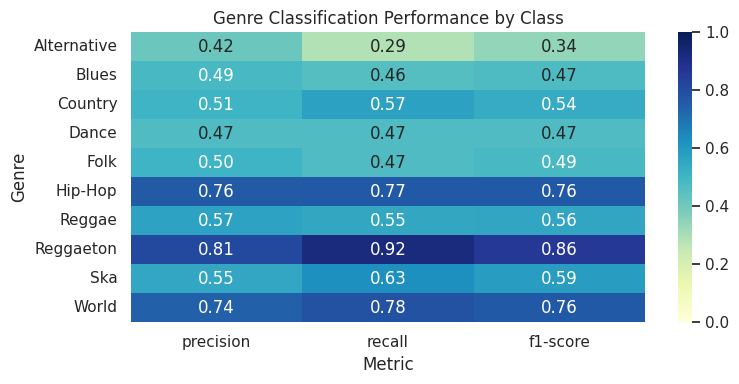

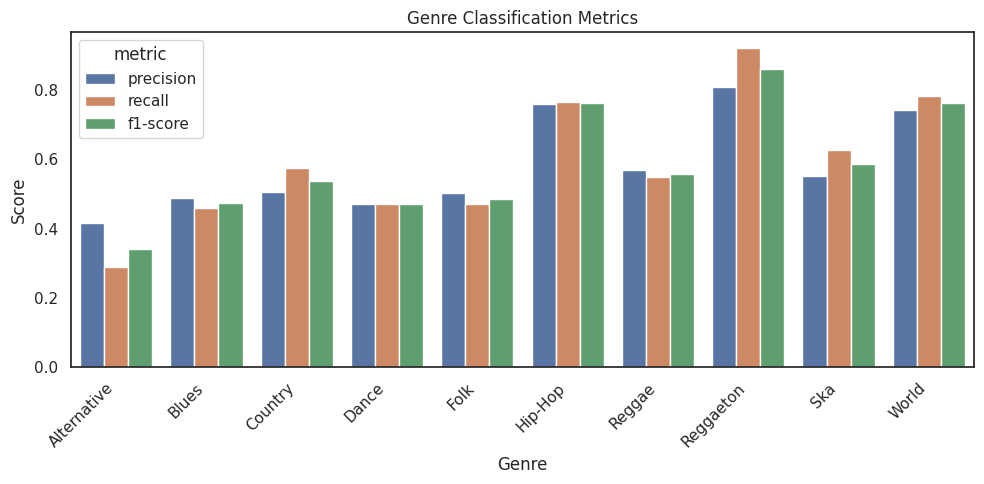

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# keep only actual classes (remove accuracy / macro avg rows)
metrics_df = report_df[report_df["label"].isin(le.classes_)].copy()

metrics_df["precision"] = pd.to_numeric(metrics_df["precision"], errors="coerce")
metrics_df["recall"] = pd.to_numeric(metrics_df["recall"], errors="coerce")
metrics_df["f1-score"] = pd.to_numeric(metrics_df["f1-score"], errors="coerce")

heatmap_data = metrics_df.set_index("label")[["precision", "recall", "f1-score"]]

plt.figure(figsize=(8, max(4, 0.4 * len(heatmap_data))))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    fmt=".2f"
)

plt.title("Genre Classification Performance by Class")
plt.xlabel("Metric")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()
plot_df = metrics_df.melt(
    id_vars="label",
    value_vars=["precision", "recall", "f1-score"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=plot_df,
    x="label",
    y="score",
    hue="metric"
)

plt.title("Genre Classification Metrics")
plt.xlabel("Genre")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()